# 04 · xFG Success Modeling (M0–M2)

Purpose: Fit cloglog success models for field goal attempts, then add inverse-propensity weights (from π(X)) for kicks.

Inputs:
- data/fg_all.csv (from 01_data_prep.ipynb)
- reports/attempt_pi/attempt_pi_oof_predictions.csv (from 03_attempt_pi.ipynb)

Outputs:
- reports/xfg_success/metrics_by_model.csv
- reports/xfg_success/preds_by_model_sample.csv
- reports/xfg_success/figs/xfg_calibration_distance.png

Sections:
- Parameters & Modes
- Imports (install if missing)
- Utilities & Helpers
- Data Load & Peek
- M0–M2 Model Fits (glmmTMB)
- Artifacts
- Session Info

In [22]:
# Parameters
PROJECT_ROOT <- normalizePath('G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model', winslash = '\\', mustWork = FALSE)
reference_dir <- file.path(PROJECT_ROOT, 'Reference')
data_dir <- file.path(PROJECT_ROOT, 'data')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
config_path <- file.path(PROJECT_ROOT, 'config', 'params.yaml')
models_dir <- file.path(PROJECT_ROOT, 'models')

if (!dir.exists(reports_dir)) {
  dir.create(reports_dir, recursive = TRUE, showWarnings = FALSE)
}

# subdir for xfg
reports_xfg_dir <- file.path(reports_dir, 'xfg_success')
if (!dir.exists(reports_xfg_dir)) dir.create(reports_xfg_dir, recursive = TRUE)

SEASONS <- 2015:2024

# RE toggle for player drift by season
ADD_PLAYER_SEASON_RE <- TRUE  # set TRUE to add (1 | kicker_player_id:season)

# Regularization controls
REG_CV_FOLDS <- 5
REG_USE_LAMBDA <- 'lambda.1se'  # 'lambda.min' | 'lambda.1se'
REG_REPEATS <- 10  # number of repeated CV runs for stability/selection frequency

# Distance spline controls (manual knots like ref_modeling)
DIST_KNOTS <- c(28,38,48,58)
DIST_BOUNDS <- c(18,70)

set.seed(20240517)

In [23]:
# Imports — install if missing

dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'yaml', 'rlang', 'scales', 'glmnet'
)

installed <- rownames(installed.packages())

for (pkg in dependencies) {
  if (!pkg %in% installed) {
    install.packages(pkg)
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

### Function Index

- `get_schema()` — quick schema preview of a data frame.
- `ensure_columns()` — add defaulted columns when missing.
- `add_time_features()` — derive common time and score features.
- `clip_probabilities()` — constrain probabilities to [min, max].
- `stabilize_weights()` — compute stabilized weights with optional grouping.
- `effective_sample_size()` — calculate ESS from weights.
- `calibration_summary()` — summarize calibration by bins.
- `plot_calibration()` — simple calibration scatter + smoother.


In [24]:
# Restored utilities: splines, metrics, scoring, calibration by distance
# These are strict helpers with no hidden fallbacks.

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) {
  stopifnot(length(y) == length(p))
  y <- as.numeric(y)
  p <- pmin(pmax(as.numeric(p), 0), 1)
  mean((y - p)^2, na.rm = TRUE)
}

logloss <- function(y, p, eps = 1e-15) {
  stopifnot(length(y) == length(p))
  y <- as.numeric(y)
  p <- pmin(pmax(as.numeric(p), eps), 1 - eps)
  -mean(y * log(p) + (1 - y) * log(1 - p), na.rm = TRUE)
}

# Generic probability scoring for GLM/GLMM models
score_probs <- function(model, data) {
  pr <- stats::predict(model, newdata = data, type = "response")
  as.numeric(pmin(pmax(pr, 0), 1))
}

# Build aggregated calibration table by distance for one probability column
make_calib_by_dist <- function(df, p_col, dist_col = 'kick_distance', y_col = 'kick_made', breaks = seq(15,70,5), right = FALSE, include.lowest = TRUE) {
  stopifnot(is.data.frame(df), p_col %in% names(df), dist_col %in% names(df), y_col %in% names(df))
  df %>%
    dplyr::mutate(
      dist_bin = cut(.data[[dist_col]], breaks = breaks, right = right, include.lowest = include.lowest)
    ) %>%
    dplyr::group_by(dist_bin) %>%
    dplyr::summarise(
      n = dplyr::n(),
      obs = mean(.data[[y_col]], na.rm = TRUE),
      est = mean(.data[[p_col]], na.rm = TRUE),
      .groups = 'drop'
    ) %>%
    dplyr::arrange(dist_bin)
}

# Calibration slope for three models (returns tidy table)
cal_slope_three <- function(df, prob_cols_named, treatment_label = NA_character_) {
  stopifnot(is.data.frame(df))
  out <- lapply(names(prob_cols_named), function(nm) {
    col <- prob_cols_named[[nm]]
    stopifnot(col %in% names(df))
    p <- pmin(pmax(df[[col]], 1e-6), 1 - 1e-6)
    lp <- qlogis(p)
    # enforce binary response; fallback to OLS if not strictly {0,1}
    y_raw <- df$kick_made
    y_bin <- as.integer(round(as.numeric(y_raw)))
    if (any(!is.finite(y_bin))) y_bin[!is.finite(y_bin)] <- NA_integer_
    if (all(y_bin %in% c(0L, 1L) | is.na(y_bin))) {
      fit <- suppressWarnings(stats::glm(y_bin ~ lp, family = stats::binomial()))
      co <- summary(fit)$coefficients
      slope <- unname(co[2, 1])
      se <- unname(co[2, 2])
    } else {
      # Non-binary outcomes detected; use linear model for a calibrated slope proxy
      y_num <- as.numeric(y_raw)
      fit <- stats::lm(y_num ~ lp)
      co <- summary(fit)$coefficients
      slope <- unname(co[2, 1])
      se <- unname(co[2, 2])
    }
    tibble::tibble(model = nm, slope = slope, se = se, treatment = treatment_label)
  })
  dplyr::bind_rows(out)
}

# Function to calculate performance and calibration metrics
make_metrics <- function(df, model_name) {
  stopifnot(c(".pred", "kick_made", "kick_distance") %in% names(df))

  # Overall metrics
  brier_score <- brier(df$kick_made, df$.pred)
  log_loss <- logloss(df$kick_made, df$.pred)
  roc_auc <- pROC::auc(df$kick_made, df$.pred)

  # Calibration regression
  cal_mod <- stats::glm(kick_made ~ .pred, data = df, family = "binomial")
  cal_summary <- summary(cal_mod)
  cal_slope <- cal_summary$coefficients[2, 1]
  cal_slope_se <- cal_summary$coefficients[2, 2]
  cal_intercept <- cal_summary$coefficients[1, 1]

  # Binned calibration
  cal_table <- make_calib_by_dist(df, p_col = ".pred")

  # Combine into a single-row tibble
  tibble::tibble(
    model = model_name,
    brier = brier_score,
    log_loss = log_loss,
    auc = as.numeric(roc_auc),
    cal_slope = cal_slope,
    cal_slope_se = cal_slope_se,
    cal_intercept = cal_intercept,
    cal_data = list(cal_table)
  )
}


In [25]:
# ---- Minimal calibration plotting helpers ----
# Inputs (aggregated):
#   dist_bin: factor/character bin labels
#   n:        integer count (>=0)
#   obs:      observed rate in [0,1]
#   est:      estimated rate in [0,1]
# Optional:
#   model:    character, for multi-model comparisons

# ---------- Shared utilities ----------
.calib_validate <- function(df, need_model = NA) {
  req <- c("dist_bin","n","obs","est")
  if (!all(req %in% names(df))) stop("calibration table must have: dist_bin, n, obs, est")
  stopifnot(all(is.finite(df$n)), all(df$n >= 0))
  if (any(df$obs < 0 | df$obs > 1, na.rm = TRUE)) stop("obs must be in [0,1]")
  if (any(df$est < 0 | df$est > 1, na.rm = TRUE)) stop("est must be in [0,1]")
  if (isTRUE(need_model) && !"model" %in% names(df)) stop("`model` column required")
  if (identical(need_model, FALSE) && "model" %in% names(df)) df$model <- NULL
  df
}

.calib_ci <- function(df, level = 0.95) {
  if (!("obs" %in% names(df) && "n" %in% names(df))) return(df)
  z <- qnorm(1 - (1 - level)/2)
  dplyr::mutate(
    df,
    se    = dplyr::if_else(n > 0 & !is.na(obs), sqrt(pmax(obs*(1-obs)/pmax(1, n), 0)), NA_real_),
    ci_lo = pmax(0, obs - z*se),
    ci_hi = pmin(1, obs + z*se)
  )
}

.calib_theme <- function() {
  ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(
      panel.grid.minor = ggplot2::element_blank(),
      axis.title.x = ggplot2::element_text(margin = ggplot2::margin(t = 6)),
      axis.title.y = ggplot2::element_text(margin = ggplot2::margin(r = 6)),
      legend.position = "top",
      legend.title = ggplot2::element_blank()
    )
}

# ---------- Single-model calibration ----------
calib_plot <- function(
  df, title = NULL, show_ci = TRUE, show_n = TRUE, ci_level = 0.95,
  save_path = NULL, width = 11, height = 6, dpi = 300
) {
  df <- .calib_validate(df, need_model = FALSE) |>
    dplyr::filter(is.finite(n), is.finite(obs), is.finite(est)) |>
    dplyr::mutate(est = pmin(pmax(est, 0), 1))
  if (nrow(df) == 0) stop("no valid rows to plot")

  if (show_ci) df <- .calib_ci(df, level = ci_level)

  p <- ggplot2::ggplot(df, ggplot2::aes(x = dist_bin)) +
    ggplot2::geom_col(ggplot2::aes(y = obs), fill = "grey85", color = "grey60", width = 0.9) +
    ggplot2::geom_line(ggplot2::aes(y = est, group = 1), linewidth = 0.7, color = "steelblue") +
    ggplot2::geom_point(ggplot2::aes(y = est), size = 2.2, color = "steelblue") +
    { if (show_ci) ggplot2::geom_errorbar(ggplot2::aes(ymin = ci_lo, ymax = ci_hi), width = 0.18, color = "grey35") } +
    { if (show_n) ggplot2::geom_text(ggplot2::aes(y = 0, label = n), vjust = 1.6, size = 3) } +
    ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    ggplot2::labs(x = "Kick distance (binned)", y = "Rate", title = title,
                  caption = if (show_n) "Bars = Observed • Line/points = Estimated • Labels = n" else NULL) +
    .calib_theme()

  if (!is.null(save_path)) ggplot2::ggsave(save_path, p, width = width, height = height, dpi = dpi)
  p
}

calib_compare_plot <- function(
  df, title = NULL, show_bars = TRUE,
  save_path = NULL, width = 11, height = 6, dpi = 300
) {
  df <- .calib_validate(df, need_model = TRUE) |>
    dplyr::filter(is.finite(n), is.finite(obs), is.finite(est)) |>
    dplyr::mutate(est = pmin(pmax(est, 0), 1))

  # one bar per bin (shared observed rate); choose your aggregator:
  # if obs is identical per bin across models, use first(); otherwise average.
  bars_df <- df |>
    dplyr::group_by(dist_bin) |>
    dplyr::summarise(
      obs = mean(obs, na.rm = TRUE),
      n   = sum(n, na.rm = TRUE),
      .groups = "drop"
    )

  p <- ggplot2::ggplot(df, ggplot2::aes(x = dist_bin)) +
    { if (show_bars)
        ggplot2::geom_col(
          data = bars_df,
          ggplot2::aes(x = dist_bin, y = obs),
          fill = "grey88", color = "grey60", width = 0.9,
          inherit.aes = FALSE
        )
      else NULL } +
    ggplot2::geom_line(ggplot2::aes(y = est, color = model, group = model), linewidth = 0.7) +
    ggplot2::geom_point(ggplot2::aes(y = est, color = model), size = 2) +
    ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    ggplot2::labs(x = "Kick distance (binned)", y = "Rate", title = title) +
    .calib_theme()

  if (!is.null(save_path)) ggplot2::ggsave(save_path, p, width = width, height = height, dpi = dpi)
  p
}


# ---------- Calibration slope bars ----------
slope_bar_plot <- function(df, title = NULL) {
  # expects: model, treatment, slope, se
  ggplot2::ggplot(df, ggplot2::aes(x = model, y = slope, fill = treatment)) +
    ggplot2::geom_col(position = ggplot2::position_dodge(width = 0.7), width = 0.6) +
    ggplot2::geom_errorbar(
      ggplot2::aes(ymin = slope - 1.96 * se, ymax = slope + 1.96 * se),
      position = ggplot2::position_dodge(width = 0.7), width = 0.2
    ) +
    ggplot2::geom_hline(yintercept = 1, linetype = 2) +
    ggplot2::labs(title = title, x = NULL, y = "Calibration slope (ideal = 1)") +
    .calib_theme()
}

# ---------- Aliases to match your existing calls ----------
plot_calib_by_dist_agg <- function(cal_df, title = NULL, show_ci = TRUE, show_n = TRUE, ci_level = 0.95) {
  p <- calib_plot(cal_df, title = title, show_ci = show_ci, show_n = show_n, ci_level = ci_level)
  list(plot = p,
       obs_agg = dplyr::select(cal_df, dist_bin, n, obs),
       est_df  = dplyr::select(cal_df, dist_bin, est))
}
plot_calib        <- function(cal_df, title, save_path = NULL, width = 11, height = 6, dpi = 300) calib_plot(cal_df, title, save_path = save_path, width = width, height = height, dpi = dpi)
plot_calib_compare<- function(cal_df, title, save_path = NULL, width = 11, height = 6, dpi = 300) calib_compare_plot(cal_df, title, save_path = save_path, width = width, height = height, dpi = dpi)
plot_cal_by_dist  <- function(cal_df, title, save_path = NULL, width = 11, height = 6, dpi = 300) calib_plot(cal_df, title, save_path = save_path, width = width, height = height, dpi = dpi)
plot_cal_cv       <- function(cal_df, title, save_path = NULL, width = 11, height = 6, dpi = 300) calib_plot(cal_df, title, save_path = save_path, width = width, height = height, dpi = dpi)
plot_slope_bars   <- function(df, title) slope_bar_plot(df, title)


In [26]:
# Unit test: play-level generation -> aggregated calibration -> plots

library(dplyr)
set.seed(123)

# bins
bin_breaks <- seq(15, 65, by = 10)
bin_labels <- paste0("[", bin_breaks[-length(bin_breaks)], ",", bin_breaks[-1], ")")

# simulate plays uniformly across bins
n_per_bin <- 200
sim <- do.call(rbind, lapply(seq_along(bin_labels), function(i) {
  bin <- bin_labels[i]
  dist_mid <- mean(c(bin_breaks[i], bin_breaks[i+1]))
  # base prob decreases with distance (toy)
  base_p <- plogis(2.5 - 0.05 * (dist_mid - 35))
  p_m1 <- pmin(pmax(base_p + rnorm(n_per_bin, 0, 0.03), 0.01), 0.99)
  p_m2 <- pmin(pmax(base_p + rnorm(n_per_bin, 0, 0.03), 0.01), 0.99)
  y <- rbinom(n_per_bin, 1, base_p)
  data.frame(dist_bin = bin, kick_made = y, p_m1 = p_m1, p_m2 = p_m2, stringsAsFactors = FALSE)
}))

# aggregated calibration tables
cal_m1 <- sim %>% group_by(dist_bin) %>% summarise(n = n(), obs = mean(kick_made), est = mean(p_m1), .groups='drop')
cal_m2 <- sim %>% group_by(dist_bin) %>% summarise(n = n(), obs = mean(kick_made), est = mean(p_m2), .groups='drop')
cal_cmp <- bind_rows(mutate(cal_m1, model = 'm1'), mutate(cal_m2, model = 'm2'))

# run plots
res_single <- plot_calib(cal_m1, title = 'Unit test: single model')
res_cmp    <- plot_calib_compare(cal_cmp, title = 'Unit test: compare two models')

# assertions
stopifnot(all(res_single$obs_agg$obs >= 0 & res_single$obs_agg$obs <= 1))
stopifnot(all(res_single$est_df$est >= 0 & res_single$est_df$est <= 1))
stopifnot(all(res_cmp$obs_agg$obs >= 0 & res_cmp$obs_agg$obs <= 1))
stopifnot(all(res_cmp$est_df$est >= 0 & res_cmp$est_df$est <= 1))

cat('Unit test passed: calibration plotting helpers OK.\n')


Unit test passed: calibration plotting helpers OK.


In [27]:
# Data Load & Peek

fg_path <- file.path(data_dir, 'fg_all.csv')
stopifnot(file.exists(fg_path))
fg_all <- readr::read_csv(fg_path, show_col_types = FALSE)

# keep only seasons in SEASONS
fg_all <- fg_all %>% dplyr::filter(as.character(season) %in% as.character(SEASONS))

# Coerce keys for joins
fg_all <- fg_all %>%
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id),
    play_id = as.character(play_id)
  )

# Load attempt π OOF predictions (bring required columns)
oof_path <- file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')
stopifnot(file.exists(oof_path))
preds_oof <- readr::read_csv(oof_path, show_col_types = FALSE) %>%
  dplyr::mutate(
    season = as.integer(season),
    game_id = as.character(game_id),
    play_id = as.character(play_id)
  ) %>%
  dplyr::select(season, game_id, play_id, p_hat_attempt_clipped, w_ipw_final)

# Build kicks+PATs base frame
kicks_base <- fg_all %>%
  dplyr::filter(play_type_original %in% c('field_goal', 'extra_point')) %>%
  dplyr::mutate(
    is_pat = as.integer(play_type_original == 'extra_point'),
    kick_result = dplyr::case_when(
      is_pat == 1L & kick_result %in% c('made', 'good') ~ 'made',
      TRUE ~ tolower(as.character(kick_result))
    )
  ) %>%
  # join attempt π predictions / weights
  dplyr::left_join(preds_oof, by = c('season', 'game_id', 'play_id'))

# Compute reference values among FGs (is_pat == 0)
fg_ref <- kicks_base %>% dplyr::filter(is_pat == 0L)

# Use p_hat_attempt_clipped as the canonical p_hat
p_hat_vec <- fg_ref$p_hat_attempt_clipped
p_hat_vec <- p_hat_vec[!is.na(p_hat_vec) & is.finite(p_hat_vec)]
max_p_hat_fg <- if (length(p_hat_vec) > 0) max(p_hat_vec, na.rm = TRUE) else (1 - 1e-6)
if (!is.finite(max_p_hat_fg)) max_p_hat_fg <- 1 - 1e-6

# Use w_ipw_final as the canonical FG weight
wvec_ipw <- fg_ref$w_ipw_final
wvec_ipw <- wvec_ipw[!is.na(wvec_ipw) & is.finite(wvec_ipw)]
min_ipw_w_fg <- if (length(wvec_ipw) > 0) min(wvec_ipw, na.rm = TRUE) else 1
if (!is.finite(min_ipw_w_fg)) min_ipw_w_fg <- 1

# Assign PAT fallback values (make data complete). Only overwrite PAT rows.
# Overwrite weight_multinom_hajek with the canonical IPW for compatibility downstream.
kicks_base <- kicks_base %>%
  dplyr::mutate(
    # populate a consistent p_hat_multinom column from p_hat_attempt_clipped (PATs get FG max)
    p_hat_multinom = dplyr::case_when(
      is_pat == 1L ~ as.numeric(max_p_hat_fg),
      TRUE ~ as.numeric(p_hat_attempt_clipped)
    ),
    weight_multinom_hajek = dplyr::case_when(
      is_pat == 1L ~ as.numeric(min_ipw_w_fg),
      TRUE ~ as.numeric(w_ipw_final)  # canonical FG weight
    )
  )

# Ensure numeric type
kicks_base <- kicks_base %>%
  dplyr::mutate(
    weight_multinom_hajek = as.numeric(weight_multinom_hajek),
    p_hat_multinom = as.numeric(p_hat_multinom)
  )


# Quick checks: confirm all kicks have a hajek (now IPW) weight and a p_hat
n_total <- nrow(kicks_base)
n_missing_p_hat <- sum(is.na(kicks_base$p_hat_multinom))
n_missing_hajek <- sum(is.na(kicks_base$weight_multinom_hajek))

message(sprintf("kicks_base rows: %d; missing p_hat_multinom: %d; missing weight_multinom_hajek: %d",
                n_total, n_missing_p_hat, n_missing_hajek))

# Fail fast if anything still missing
stopifnot(n_missing_p_hat == 0, n_missing_hajek == 0)

# Outcome encodings and two datasets
kicks_blocks_as_miss <- kicks_base %>%
  dplyr::mutate(kick_made = as.integer(kick_result == 'made'))

kicks_blocks_excluded <- kicks_base %>%
  dplyr::filter(kick_result != 'blocked' | is.na(kick_result)) %>%
  dplyr::mutate(kick_made = as.integer(kick_result == 'made'))

# Sanity check: IPW weight distributions after merge (plot)
weight_check <- kicks_base %>%
  dplyr::transmute(is_pat, is_fg = 1L - is_pat, weight_multinom_hajek) %>%
  dplyr::mutate(type = ifelse(is_pat == 1L, 'PAT', 'FG'))

  weight_stats <- weight_check %>%
    dplyr::group_by(type) %>%
    dplyr::summarise(
      n = dplyr::n(),
      mean = mean(weight_multinom_hajek, na.rm = TRUE),
      sd = sd(weight_multinom_hajek, na.rm = TRUE),
      median = median(weight_multinom_hajek, na.rm = TRUE),
      p25 = quantile(weight_multinom_hajek, 0.25, na.rm = TRUE),
      p75 = quantile(weight_multinom_hajek, 0.75, na.rm = TRUE),
      min = min(weight_multinom_hajek, na.rm = TRUE),
      max = max(weight_multinom_hajek, na.rm = TRUE),
      ess = (sum(weight_multinom_hajek, na.rm = TRUE)^2) / sum(weight_multinom_hajek^2, na.rm = TRUE),
      ess_frac = ess/n,
      .groups = 'drop'
    );



p_w <- ggplot2::ggplot(weight_check, ggplot2::aes(x = weight_multinom_hajek, fill = type)) +
  ggplot2::geom_histogram(position = 'identity', alpha = 0.6, bins = 60, colour = 'white') +
  ggplot2::scale_fill_brewer(palette = 'Set2') +
  ggplot2::labs(title = 'IPW weights after merge (PAT assigned min IPW)', x = 'Weight (canonical IPW)', y = 'Count', fill = 'Type') +
  ggplot2::theme_minimal(base_size = 12)

fig_dir <- file.path(reports_dir, 'xfg_success', 'figs'); if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)
try(ggplot2::ggsave(file.path(fig_dir, 'sanity_weights_ipw.png'), p_w, width = 9, height = 5, dpi = 200), silent = TRUE)

list(weight_stats, head(kicks_blocks_as_miss, 3), head(kicks_blocks_excluded, 3))


kicks_base rows: 23373; missing p_hat_multinom: 0; missing weight_multinom_hajek: 0



[[1]]
# A tibble: 2 × 11
  type      n  mean    sd median   p25   p75   min   max    ess ess_frac
  <chr> <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>  <dbl>    <dbl>
1 FG    10624 0.947 0.885  0.698 0.662 0.829 0.617 8.55   5670.    0.534
2 PAT   12749 0.617 0      0.617 0.617 0.617 0.617 0.617 12749     1    

[[2]]
# A tibble: 3 × 96
  game_id play_id old_game_id season  week season_type playoffs   qtr game_date 
  <chr>   <chr>         <dbl>  <int> <dbl> <chr>          <dbl> <dbl> <date>    
1 2015_0… 580      2015091309   2015     1 REG                0     1 2015-09-13
2 2015_0… 824      2015091309   2015     1 REG                0     1 2015-09-13
3 2015_0… 1357     2015091309   2015     1 REG                0     2 2015-09-13
# ℹ 87 more variables: home_team <chr>, away_team <chr>, posteam <chr>,
#   defteam <chr>, game_seconds_remaining <dbl>,
#   quarter_seconds_remaining <dbl>, score_differential <dbl>,
#   yardline_100 <dbl>, ydstogo <dbl>, wp <dbl>, home_wp <dbl>, epa <dbl>,
#   posteam_timeouts_remaining <dbl>, defteam_timeouts_remaining <dbl>,
#   goal_to_go <dbl>, is_ot <lgl>, roof <chr>, surface <chr>, temp <dbl>,
#   wind <dbl>, weather <chr>, stadium_id <chr>, stadium <chr>, …

[[3]]
# A tibble: 3 × 96
  game_id play_id old_game_id season  week season_type playoffs   qtr game_date 
  <chr>   <chr>         <dbl>  <int> <dbl> <chr>          <dbl> <dbl> <date>    
1 2015_0… 580      2015091309   2015     1 REG                0     1 2015-09-13
2 2015_0… 824      2015091309   2015     1 REG                0     1 2015-09-13
3 2015_0… 1357     2015091309   2015     1 REG                0     2 2015-09-13
# ℹ 87 more variables: home_team <chr>, away_team <chr>, posteam <chr>,
#   defteam <chr>, game_seconds_remaining <dbl>,
#   quarter_seconds_remaining <dbl>, score_differential <dbl>,
#   yardline_100 <dbl>, ydstogo <dbl>, wp <dbl>, home_wp <dbl>, epa <dbl>,
#   posteam_timeouts_remaining <dbl>, defteam_timeouts_remaining <dbl>,
#   goal_to_go <dbl>, is_ot <lgl>, roof <chr>, surface <chr>, temp <dbl>,
#   wind <dbl>, weather <chr>, stadium_id <chr>, stadium <chr>, …

In [28]:
# ================== Modeling formula setup — splines + use precomputed IPW weights ==================

# --- Preconditions ---
if (!exists('kicks_blocks_as_miss') || !exists('kicks_blocks_excluded')) {
  stop('Expected kicks_blocks_* frames to exist from data prep cell.')
}

# --- Distance B-splines (keep 'dist_bs_*' names) ---
dist_mat_A <- build_distance_bs(kicks_blocks_as_miss$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
dist_mat_B <- build_distance_bs(kicks_blocks_excluded$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)

kicks_A <- dplyr::bind_cols(kicks_blocks_as_miss, dist_mat_A)
kicks_B <- dplyr::bind_cols(kicks_blocks_excluded, dist_mat_B)

# --- Light coalescing for variables used in formulas (avoid NAs) ---
coalesce_for_model <- function(df) {
  df %>% dplyr::mutate(
    indoors = dplyr::coalesce(as.integer(indoors), 0L),
    high_altitude = dplyr::coalesce(as.integer(high_altitude), 0L),
    is_rain_showers = dplyr::coalesce(as.integer(is_rain_showers), 0L),
    is_snow_sleet = dplyr::coalesce(as.integer(is_snow_sleet), 0L),
    wind_z = as.numeric(dplyr::coalesce(wind_z, 0)),
    temp_z = as.numeric(dplyr::coalesce(temp_z, 0)),
    leverage_z = as.numeric(dplyr::coalesce(leverage_z, 0)),
    is_ot = dplyr::coalesce(as.integer(is_ot), 0L),
    iced = dplyr::coalesce(as.integer(iced), 0L),
    clock_running = dplyr::coalesce(as.integer(clock_running), 0L),
    posteam_timeouts_remaining = as.numeric(dplyr::coalesce(posteam_timeouts_remaining, 0)),
    kicker_age_z = as.numeric(dplyr::coalesce(kicker_age_z, 0)),
    kicker_experience_z = as.numeric(dplyr::coalesce(kicker_experience_z, 0)),
    stadium_id = dplyr::coalesce(as.character(stadium_id), 'unknown_stadium'),
    kicker_player_id = dplyr::coalesce(as.character(kicker_player_id), 'unknown_kicker')
  )
}
kicks_A <- coalesce_for_model(kicks_A)
kicks_B <- coalesce_for_model(kicks_B)

# --- Term strings from actual dist spline columns present in kicks_A/B ---
dist_cols <- colnames(dist_mat_A)
dist_term  <- paste(dist_cols, collapse = ' + ')
wind_terms <- paste(sprintf('(%s):wind_z', dist_cols), collapse = ' + ')
temp_terms <- paste(sprintf('(%s):temp_z',  dist_cols), collapse = ' + ')

# Create FG-only datasets for downstream FG-specific modeling (if not already present)
if (!exists('fg_A')) fg_A <- kicks_A %>% dplyr::filter(is_pat == 0L)
if (!exists('fg_B')) fg_B <- kicks_B %>% dplyr::filter(is_pat == 0L)

# Keep downstream code aware of the current dist term names
message('Modeling setup complete — distance spline bases built and key variables coalesced. Using precomputed weights where available.')


Modeling setup complete — distance spline bases built and key variables coalesced. Using precomputed weights where available.



In [29]:
# Show % missing for kicks_A and fg_A

stopifnot(exists("kicks_A"), exists("fg_A"))

make_na_summary <- function(df, ds_name) {
    tibble::tibble(
        dataset = ds_name,
        column = names(df),
        n_missing = vapply(df, function(x) sum(is.na(x)), integer(1)),
        n_total = nrow(df)
    ) %>%
        dplyr::mutate(
            pct_missing = 100 * n_missing / pmax(n_total, 1),
            pct_complete = 100 - pct_missing
        ) %>%
        dplyr::arrange(dplyr::desc(pct_missing))
}

na_kicks_A <- make_na_summary(kicks_A, "kicks_A")
na_fg_A    <- make_na_summary(fg_A,    "fg_A")

# Print concise tables (only columns with any missing values first)
message("kicks_A — columns with missing values:")
print(na_kicks_A %>% dplyr::filter(n_missing > 0) %>% dplyr::slice_head(n = 50))

message("fg_A — columns with missing values:")
print(na_fg_A %>% dplyr::filter(n_missing > 0) %>% dplyr::slice_head(n = 50))

# If you want full summaries as well:
message("Full NA summary for kicks_A (top 50 rows shown):")
print(na_kicks_A %>% dplyr::slice_head(n = 50))

message("Full NA summary for fg_A (top 50 rows shown):")
print(na_fg_A %>% dplyr::slice_head(n = 50))

#Save FG_A and FG_B to data directory for modeling scripts
fg_a_path <- file.path(data_dir, 'fg_A.csv')
fg_b_path <- file.path(data_dir, 'fg_B.csv')
readr::write_csv(fg_A, fg_a_path)
readr::write_csv(fg_B, fg_b_path)

kicks_A — columns with missing values:



# A tibble: 18 × 6
   dataset column                n_missing n_total pct_missing pct_complete
   <chr>   <chr>                     <int>   <int>       <dbl>        <dbl>
 1 kicks_A down                      23373   23373     100             0   
 2 kicks_A prev_timeout_team         21638   23373      92.6           7.42
 3 kicks_A field_goal_result         12749   23373      54.5          45.5 
 4 kicks_A p_hat_attempt_clipped     12749   23373      54.5          45.5 
 5 kicks_A w_ipw_final               12749   23373      54.5          45.5 
 6 kicks_A extra_point_result        10624   23373      45.5          54.5 
 7 kicks_A weather_first              2650   23373      11.3          88.7 
 8 kicks_A weather                     395   23373       1.69         98.3 
 9 kicks_A weather_clean               395   23373       1.69         98.3 
10 kicks_A wp_make_hat                 138   23373       0.590        99.4 
11 kicks_A wp_miss_hat                 138   23373       0.590       

fg_A — columns with missing values:



# A tibble: 15 × 6
   dataset column             n_missing n_total pct_missing pct_complete
   <chr>   <chr>                  <int>   <int>       <dbl>        <dbl>
 1 fg_A    extra_point_result     10624   10624     100              0  
 2 fg_A    down                   10624   10624     100              0  
 3 fg_A    prev_timeout_team       9218   10624      86.8           13.2
 4 fg_A    weather_first           1213   10624      11.4           88.6
 5 fg_A    weather                  181   10624       1.70          98.3
 6 fg_A    weather_clean            181   10624       1.70          98.3
 7 fg_A    wp_make_hat              138   10624       1.30          98.7
 8 fg_A    wp_miss_hat              138   10624       1.30          98.7
 9 fg_A    wp_make_hat_rules        138   10624       1.30          98.7
10 fg_A    wp_miss_hat_rules        138   10624       1.30          98.7
11 fg_A    pred_hat_post            138   10624       1.30          98.7
12 fg_A    prev_timeout         

Full NA summary for kicks_A (top 50 rows shown):



# A tibble: 50 × 6
   dataset column                n_missing n_total pct_missing pct_complete
   <chr>   <chr>                     <int>   <int>       <dbl>        <dbl>
 1 kicks_A down                      23373   23373     100             0   
 2 kicks_A prev_timeout_team         21638   23373      92.6           7.42
 3 kicks_A field_goal_result         12749   23373      54.5          45.5 
 4 kicks_A p_hat_attempt_clipped     12749   23373      54.5          45.5 
 5 kicks_A w_ipw_final               12749   23373      54.5          45.5 
 6 kicks_A extra_point_result        10624   23373      45.5          54.5 
 7 kicks_A weather_first              2650   23373      11.3          88.7 
 8 kicks_A weather                     395   23373       1.69         98.3 
 9 kicks_A weather_clean               395   23373       1.69         98.3 
10 kicks_A wp_make_hat                 138   23373       0.590        99.4 
# ℹ 40 more rows


Full NA summary for fg_A (top 50 rows shown):



# A tibble: 50 × 6
   dataset column             n_missing n_total pct_missing pct_complete
   <chr>   <chr>                  <int>   <int>       <dbl>        <dbl>
 1 fg_A    extra_point_result     10624   10624      100             0  
 2 fg_A    down                   10624   10624      100             0  
 3 fg_A    prev_timeout_team       9218   10624       86.8          13.2
 4 fg_A    weather_first           1213   10624       11.4          88.6
 5 fg_A    weather                  181   10624        1.70         98.3
 6 fg_A    weather_clean            181   10624        1.70         98.3
 7 fg_A    wp_make_hat              138   10624        1.30         98.7
 8 fg_A    wp_miss_hat              138   10624        1.30         98.7
 9 fg_A    wp_make_hat_rules        138   10624        1.30         98.7
10 fg_A    wp_miss_hat_rules        138   10624        1.30         98.7
# ℹ 40 more rows


In [30]:
# ================= Create K-fold CV split on game_id =================
# Create a K-fold split based on game_id to prevent data leakage.
# This fold map will be saved and reused for all CV experiments.

K <- 5
set.seed(2025) # for reproducibility

# Create a map from game_id to a fold ID
fold_map <- fg_B %>%
  dplyr::distinct(game_id) %>%
  dplyr::mutate(fold = sample(rep(1:K, length.out = dplyr::n())))

# Create a vector of fold IDs for each row in fg_B
foldid <- fold_map$fold[match(fg_B$game_id, fold_map$game_id)]
stopifnot(length(foldid) == nrow(fg_B))
fg_B$fold <- foldid

# --- Save fold map and foldid vector for reuse ---
cv_fg_B_dir <- file.path(reports_dir, 'xfg_success', 'cv_fg_B')
if (!dir.exists(cv_fg_B_dir)) dir.create(cv_fg_B_dir, recursive = TRUE)
readr::write_csv(fold_map, file.path(cv_fg_B_dir, "fg_B_cv_fold_map.csv"))
readr::write_csv(tibble::tibble(foldid = foldid), file.path(cv_fg_B_dir, "fg_B_cv_foldid.csv"))

# --- Verify the split ---
fold_summary <- fg_B %>%
  dplyr::group_by(fold) %>%
  dplyr::summarise(
    n_games = dplyr::n_distinct(game_id),
    n_kicks = dplyr::n(),
    pct_kicks = n_kicks / nrow(fg_B)
  ) %>%
  dplyr::arrange(fold)

print(fold_summary)

# A tibble: 5 × 4
   fold n_games n_kicks pct_kicks
  <int>   <int>   <int>     <dbl>
1     1     540    2093     0.201
2     2     540    2092     0.201
3     3     540    2062     0.198
4     4     540    2057     0.197
5     5     540    2128     0.204


In [31]:
# ================= Elastic-net regularization on fg_B (no time_ns or score terms) =================
#New dir in xfg_reports
reports_xfg_reg_dir <- file.path(reports_dir, 'xfg_success', 'Regularization')
if (!dir.exists(reports_xfg_reg_dir)) {
  dir.create(reports_xfg_reg_dir, recursive = TRUE)
}

stopifnot(exists("fg_B"))
if (!"weight_multinom_hajek" %in% names(fg_B)) stop("fg_B missing weight_multinom_hajek. Use the weights prep cell first.")
stopifnot("kick_made" %in% names(fg_B))

# ---------- 1) Ensure distance splines present (dist_bs_*) ----------
dist_cols <- grep("^dist_bs_", names(fg_B), value = TRUE)
if (length(dist_cols) == 0) {
  if (!exists("build_distance_bs")) stop("build_distance_bs() not found; supply distance basis builder.")
  bs_aux <- build_distance_bs(fg_B$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
  colnames(bs_aux) <- paste0("dist_bs_", seq_len(ncol(bs_aux)))
  fg_B <- dplyr::bind_cols(fg_B, bs_aux)
  dist_cols <- colnames(bs_aux)
}

# ---------- 2) Candidate feature list (assume columns already coalesced) ----------
feat <- c(
  dist_cols,
  "leverage_rules","is_ot",
  "indoors","is_turf","high_altitude",
  "wind_z","temp_z","humidity_z",
  "is_rain_showers","is_snow_sleet","is_cloudy","is_hazy_fog",
  "clock_running","iced","posteam_timeouts_remaining",
  "kicker_age_z","kicker_experience_z",
  # distance interactions
  paste0(dist_cols, ":wind_z"),
  paste0(dist_cols, ":temp_z"),
  paste0(dist_cols, ":humidity_z"),
  paste0(dist_cols, ":indoors"),
  paste0(dist_cols, ":leverage_rules"),
  # env/context interactions
  "wind_z:temp_z","wind_z:indoors","temp_z:indoors",
  # kicker/clock interactions
  "kicker_age_z:kicker_experience_z",
  "clock_running:timeouts",
  # control-function main + distance×CF (if present)
  "logit_pi_c",
  paste0(dist_cols, ":logit_pi_c")
)

# keep only features actually present
feat <- feat[feat %in% names(fg_B)]

reg_df <- fg_B %>% dplyr::select(game_id, kick_made, fold, dplyr::all_of(feat))

# Drop all-NA columns (safety)
na_all <- vapply(reg_df[, feat, drop = FALSE], function(x) all(is.na(x)), logical(1))
if (any(na_all)) {
  drop_cols <- names(na_all)[na_all]
  reg_df <- reg_df %>% dplyr::select(-dplyr::all_of(drop_cols))
  feat   <- setdiff(feat, drop_cols)
}

# ---------- Build aligned X / y / mask ----------
mod_df <- reg_df %>% dplyr::mutate(.y = kick_made)

keep <- stats::complete.cases(mod_df[, c(feat, ".y"), drop = FALSE])
if (!all(keep)) message("Dropping ", sum(!keep), " rows with NA in features/target before glmnet.")
mod_df <- mod_df[keep, , drop = FALSE]

X <- stats::model.matrix(~ 0 + ., data = mod_df[, feat, drop = FALSE])
y <- mod_df$.y

# Remove near-zero variance columns
nzv <- apply(X, 2, function(col) sd(col, na.rm = TRUE) < 1e-8)
if (any(nzv)) {
  X <- X[, !nzv, drop = FALSE]
}

# ---------- Use the fold column created in the previous cell ----------
stopifnot("fold" %in% names(mod_df))
foldid <- mod_df$fold

stopifnot(nrow(X) == length(y), length(y) == length(foldid))

# ---------- Helper to run glmnet pipeline for a given weight vector and suffix ----------
run_glmnet_pipeline <- function(w_vec, suffix) {
  stopifnot(length(w_vec) == nrow(X))
  alphas <- c(0.25, 0.5, 0.75)
  cv_list <- lapply(alphas, function(a) {
    glmnet::cv.glmnet(X, y, family = "binomial", alpha = a,
                      foldid = foldid, weights = w_vec,
                      standardize = TRUE, type.measure = "deviance")
  })
  names(cv_list) <- paste0("alpha_", alphas)

  cv_stats <- tibble::tibble(
    alpha = alphas,
    lambda_min = vapply(cv_list, function(cv) cv$lambda.min, numeric(1)),
    lambda_1se = vapply(cv_list, function(cv) cv$lambda.1se, numeric(1)),
    cve_min    = vapply(cv_list, function(cv) min(cv$cvm), numeric(1))
  ) %>% dplyr::arrange(cve_min)

  best_alpha <- cv_stats$alpha[1]
  cv <- cv_list[[paste0("alpha_", best_alpha)]]

  fit_min <- glmnet::glmnet(X, y, family = "binomial", alpha = best_alpha,
                            lambda = cv$lambda.min, standardize = TRUE, weights = w_vec)
  fit_1se <- glmnet::glmnet(X, y, family = "binomial", alpha = best_alpha,
                            lambda = cv$lambda.1se, standardize = TRUE, weights = w_vec)
  lambda_relaxed <- exp(0.5 * log(cv$lambda.min) + 0.5 * log(cv$lambda.1se))
  fit_rel <- glmnet::glmnet(X, y, family = "binomial", alpha = best_alpha,
                            lambda = lambda_relaxed, standardize = TRUE, weights = w_vec)

  extract_coefs <- function(fit) {
    cm <- as.matrix(stats::coef(fit))
    tibble::tibble(term = rownames(cm), beta = as.numeric(cm)) |>
      dplyr::filter(term != "(Intercept)") |>
      dplyr::mutate(odds_ratio = exp(beta))
  }

  coef_min <- extract_coefs(fit_min)
  coef_1se <- extract_coefs(fit_1se)
  coef_rel <- extract_coefs(fit_rel)

  coef_summary <- dplyr::full_join(
    coef_1se |> dplyr::rename(beta_1se = beta, or_1se = odds_ratio),
    coef_min  |> dplyr::rename(beta_min  = beta, or_min  = odds_ratio),
    by = "term"
  ) |>
    dplyr::full_join(
      coef_rel |> dplyr::rename(beta_relaxed = beta, or_relaxed = odds_ratio),
      by = "term"
    ) |>
    dplyr::mutate(
      sel_1se = !is.na(beta_1se) & beta_1se != 0,
      sel_min = !is.na(beta_min)  & beta_min != 0,
      sel_relaxed = !is.na(beta_relaxed) & beta_relaxed != 0,
      any_selected = sel_1se | sel_min | sel_relaxed
    ) |>
    dplyr::filter(any_selected) |>
    dplyr::arrange(dplyr::desc(abs(dplyr::coalesce(beta_relaxed, 0))),
                   dplyr::desc(abs(dplyr::coalesce(beta_min, 0))))

  # save summary
  out_file <- file.path(reports_xfg_reg_dir, paste0("glmnet_regularization_summary_fg_B_", suffix, ".csv"))
  if (!dir.exists(reports_xfg_reg_dir)) dir.create(reports_xfg_reg_dir, recursive = TRUE)
  readr::write_csv(
    coef_summary |>
      dplyr::select(term, beta_1se, or_1se, beta_min, or_min, beta_relaxed, or_relaxed,
                    sel_1se, sel_min, sel_relaxed),
    out_file
  )

  list(
    suffix = suffix,
    alpha_best = best_alpha,
    lambda_min = cv$lambda.min,
    lambda_1se = cv$lambda.1se,
    lambda_relaxed = lambda_relaxed,
    coef_summary = coef_summary
  )
}

# ---------- Run unweighted (weights = 1) ----------
w_un <- rep(1, nrow(X))
res_un <- run_glmnet_pipeline(w_un, "unweighted")

# ---------- Run weighted (weights = weight_multinom_hajek) ----------
w_wt <- fg_B$weight_multinom_hajek[match(mod_df$game_id, fg_B$game_id)]
if (any(is.na(w_wt))) stop("NA found in weight_multinom_hajek aligned to mod rows; inspect inputs.")
res_wt <- run_glmnet_pipeline(w_wt, "weighted")

# Print concise summaries
cat("Unweighted best alpha:", res_un$alpha_best, "lambda.1se:", signif(res_un$lambda_1se,6), "\n")
cat("Weighted   best alpha:", res_wt$alpha_best, "lambda.1se:", signif(res_wt$lambda_1se,6), "\n")

invisible(list(unweighted = res_un, weighted = res_wt))

Unweighted best alpha: 0.75 lambda.1se: 0.00978019 
Weighted   best alpha: 0.75 lambda.1se: 0.0220371 


In [32]:
# fixed and random effects formula strings
m1_fixed <- paste(
  c(
    dist_term,
    'wind_z * temp_z + indoors + high_altitude',
    'is_rain_showers + is_snow_sleet',
    'is_ot + iced + clock_running * posteam_timeouts_remaining',
    'kicker_age_z:kicker_experience_z',
    # 'season_z',
    wind_terms,
    temp_terms
  ),
  collapse = ' + '
)


# Exploratory random effects extension for player drift by season
if (isTRUE(ADD_PLAYER_SEASON_RE)) {
  m1_re <- '(1 | stadium_id) + (1 | season:kicker_player_id)'
} else {
  m1_re <- '(1 | stadium_id) + (1 | kicker_player_id)'
}

# Simplified naming
m0_formula <- as.formula(paste('kick_made ~', dist_term))
m1_formula <- as.formula(paste('kick_made ~', m1_fixed, '+', m1_re))

m0_formula
m1_formula

kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7

kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude + 
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running * 
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z + 
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z + 
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z + 
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z + 
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z + 
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) + 
    (1 | season:kicker_player_id)

In [34]:
# ================= M0: Fit baseline models (cloglog and logit) =================
# This cell fits 8 baseline models: 4 datasets x 2 link functions.
# It will load existing models if the RDS files are found.

# --- Define model configurations ---
model_configs <- tibble::tribble(
  ~model_name, ~link, ~data_name, ~outcome,
  "m0_A_cloglog", "cloglog", "kicks_A", "kick_made",
  "m0_B_cloglog", "cloglog", "kicks_B", "kick_made",
  "m0_fg_A_cloglog", "cloglog", "fg_A", "kick_made",
  "m0_fg_B_cloglog", "cloglog", "fg_B", "kick_made",
  "m0_A_logit", "logit", "kicks_A", "kick_made",
  "m0_B_logit", "logit", "kicks_B", "kick_made",
  "m0_fg_A_logit", "logit", "fg_A", "kick_made",
  "m0_fg_B_logit", "logit", "fg_B", "kick_made",
) %>%
  dplyr::mutate(path = file.path(models_dir, "m0", paste0(model_name, ".rds")))

# --- Check for existing models or fit them ---
all_exist <- all(file.exists(model_configs$path))
if (all_exist) {
  message("All 8 M0 models (cloglog and logit) found. Loading from RDS files.")
  models <- purrr::map(model_configs$path, readRDS) %>% purrr::set_names(model_configs$model_name)
} else {
  message("One or more M0 models not found. Fitting all 8 models...")
  stopifnot(exists("m0_formula")) # Ensure m0_formula is in the environment
  models <- purrr::map(1:nrow(model_configs), function(i) {
    config <- model_configs[i, ]
    data_obj <- get(config$data_name)
    fit <- glmmTMB(m0_formula, data = data_obj, family = binomial(link = config$link),
                   control = glmmTMBControl(parallel = 6))
    saveRDS(fit, config$path)
    fit
  }) %>% purrr::set_names(model_configs$model_name)
  message("All 8 M0 models fitted and saved.")
}

# --- Make predictions ---
pred_results <- purrr::map_df(1:nrow(model_configs), function(i) {
  config <- model_configs[i, ]
  model_obj <- models[[config$model_name]]
  data_obj <- get(config$data_name)
  metrics_df <- data_obj %>%
    dplyr::mutate(
      .pred = predict(model_obj, newdata = ., type = "response"),
      kick_made = .data[[config$outcome]]
    ) %>%
    make_metrics(config$model_name)
  metrics_df %>%
    dplyr::mutate(link = config$link, dataset = config$data_name)
})

# Investigate out-of-range predictions and calibration values
pred_check <- purrr::map_df(1:nrow(model_configs), function(i) {
  config <- model_configs[i, ]
  model_obj <- models[[config$model_name]]
  data_obj <- get(config$data_name)
  preds <- data_obj %>%
    dplyr::mutate(
      .pred = predict(model_obj, newdata = ., type = "response"),
      kick_made = .data[[config$outcome]]
    )
  # Check predictions out of [0,1]
  pred_out <- preds %>% dplyr::filter(.pred < 0 | .pred > 1)
  # Calibration
  calib <- make_calib_by_dist(preds, p_col = ".pred")
  calib_out <- calib %>% dplyr::filter(obs < 0 | obs > 1 | est < 0 | est > 1)
  tibble::tibble(
    model = config$model_name,
    n_pred_out = nrow(pred_out),
    pred_min = if(nrow(pred_out)>0) min(pred_out$.pred) else NA,
    pred_max = if(nrow(pred_out)>0) max(pred_out$.pred) else NA,
    n_calib_out = nrow(calib_out),
    calib_obs_min = if(nrow(calib_out)>0) min(calib_out$obs) else NA,
    calib_est_min = if(nrow(calib_out)>0) min(calib_out$est) else NA
  )
})
print("Out-of-range diagnostics:")
print(pred_check)

#show metrics and save
metrics_summary <- pred_results %>%
  dplyr::select(dataset, link, auc, brier, log_loss, cal_slope, cal_intercept)  

metrics_summary

metrics_path <- file.path(reports_dir, "xfg_success", "m0", "m0_model_metrics_summary.csv")
if (!dir.exists(dirname(metrics_path))) dir.create(dirname(metrics_path), recursive = TRUE)
readr::write_csv(metrics_summary, metrics_path)

# --- Create calibration tables for comparison ---
calib_kicks <- pred_results %>% dplyr::filter(dataset %in% c("kicks_A", "kicks_B")) %>% tidyr::unnest(cal_data)
calib_fg <- pred_results %>% dplyr::filter(dataset %in% c("fg_A", "fg_B")) %>% tidyr::unnest(cal_data)

# --- Save calibration tables ---
calib_dir <- file.path(reports_dir, "xfg_success", "m0")
if (!dir.exists(calib_dir)) dir.create(calib_dir, recursive = TRUE)
readr::write_csv(calib_kicks, file.path(calib_dir, "m0_kicks_calibration.csv"))
readr::write_csv(calib_fg, file.path(calib_dir, "m0_fg_calibration.csv"))

# Create calibration plots (one per dataset: kicks_A, kicks_B, fg_A, fg_B)
figs_m0_dir <- file.path(reports_dir, "xfg_success", "m0", "figs")
if (!dir.exists(figs_m0_dir)) dir.create(figs_m0_dir, recursive = TRUE, showWarnings = FALSE)

# Ensure calibration tables exist (they were created above; fallback to saved CSV if not)
if (!exists("calib_kicks") || !exists("calib_fg")) {
  calib_dir <- file.path(reports_dir, "xfg_success", "m0")
  calib_kicks <- readr::read_csv(file.path(calib_dir, "m0_kicks_calibration.csv"), show_col_types = FALSE)
  calib_fg    <- readr::read_csv(file.path(calib_dir, "m0_fg_calibration.csv"), show_col_types = FALSE)
}

datasets <- list(
  kicks_A = calib_kicks %>% dplyr::filter(dataset == "kicks_A"),
  kicks_B = calib_kicks %>% dplyr::filter(dataset == "kicks_B"),
  fg_A    = calib_fg    %>% dplyr::filter(dataset == "fg_A"),
  fg_B    = calib_fg    %>% dplyr::filter(dataset == "fg_B")
)

plots_m0 <- purrr::imap(datasets, function(cal_df, ds_name) {
  # plot_calib_compare expects columns: dist_bin, n, obs, est, model
  if (!"model" %in% names(cal_df)) cal_df$model <- as.character(cal_df$model_name %||% "model")
  title <- paste0("M0 calibration by distance — ", ds_name)
  out_path <- file.path(figs_m0_dir, paste0("m0_calibration_", ds_name, ".png"))
  p <- plot_calib_compare(cal_df %>% dplyr::select(dist_bin, n, obs, est, model),
                          title = title,
                          save_path = out_path)
  message("Saved calibration plot for ", ds_name, " -> ", out_path)
  p
})

# return plots invisibly
invisible(plots_m0)


One or more M0 models not found. Fitting all 8 models...

All 8 M0 models fitted and saved.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] "Out-of-range diagnostics:"
# A tibble: 8 × 7
  model     n_pred_out pred_min pred_max n_calib_out calib_obs_min calib_est_min
  <chr>          <int> <lgl>    <lgl>          <int> <lgl>         <lgl>        
1 m0_A_clo…          0 NA       NA                 0 NA            NA           
2 m0_B_clo…          0 NA       NA                 0 NA            NA           
3 m0_fg_A_…          0 NA       NA                 0 NA            NA           
4 m0_fg_B_…          0 NA       NA                 0 NA            NA           
5 m0_A_log…          0 NA       NA                 0 NA            NA           
6 m0_B_log…          0 NA       NA                 0 NA            NA           
7 m0_fg_A_…          0 NA       NA                 0 NA            NA           
8 m0_fg_B_…          0 NA       NA                 0 NA            NA           


dataset,link,auc,brier,log_loss,cal_slope,cal_intercept
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
kicks_A,cloglog,0.7391356,0.08157901,0.2864267,7.804306,-4.582622
kicks_B,cloglog,0.7493074,0.07307359,0.2606942,8.376087,-5.033969
fg_A,cloglog,0.7644287,0.11464659,0.3673793,7.559646,-4.411231
fg_B,cloglog,0.7752712,0.10495659,0.3395934,8.085293,-4.825171
kicks_A,logit,0.7391356,0.08158307,0.2864385,7.818974,-4.595206
kicks_B,logit,0.7493074,0.07307802,0.2607170,8.395445,-5.050709
fg_A,logit,0.7644287,0.11465698,0.3674097,7.576305,-4.424566
fg_B,logit,0.7752712,0.10496448,0.3396378,8.113740,-4.848118


Saved calibration plot for kicks_A -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m0/figs/m0_calibration_kicks_A.png

Saved calibration plot for kicks_B -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m0/figs/m0_calibration_kicks_B.png

Saved calibration plot for fg_A -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m0/figs/m0_calibration_fg_A.png

Saved calibration plot for fg_B -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m0/figs/m0_calibration_fg_B.png



In [35]:
# ================= M1: Fit fixed effects + RE models (cloglog and logit) =================
# This cell fits 4 M1 models: 2 datasets (fg_A, fg_B) x 2 link functions.
# It will load existing models if the RDS files are found.

# --- Define model configurations ---
model_configs <- tibble::tribble(
  ~model_name, ~link, ~data_name, ~outcome,
  "m1_fg_A_cloglog", "cloglog", "fg_A", "kick_made",
  "m1_fg_B_cloglog", "cloglog", "fg_B", "kick_made",
  "m1_fg_A_logit", "logit", "fg_A", "kick_made",
  "m1_fg_B_logit", "logit", "fg_B", "kick_made",
) %>%
  dplyr::mutate(path = file.path(models_dir, "m1", paste0(model_name, ".rds")))

# --- Check for existing models or fit them ---
all_exist <- all(file.exists(model_configs$path))
if (all_exist) {
  message("All 4 M1 models (cloglog and logit) found. Loading from RDS files.")
  models <- purrr::map(model_configs$path, readRDS) %>% purrr::set_names(model_configs$model_name)
} else {
  message("One or more M1 models not found. Fitting all 4 models...")
  stopifnot(exists("m1_formula")) # Ensure m1_formula is in the environment
  models <- purrr::map(1:nrow(model_configs), function(i) {
    config <- model_configs[i, ]
    data_obj <- get(config$data_name)
    fit <- glmmTMB(m1_formula, data = data_obj, family = binomial(link = config$link),
                   control = glmmTMBControl(parallel = 6))
    saveRDS(fit, config$path)
    fit
  }) %>% purrr::set_names(model_configs$model_name)
  message("All 4 M1 models fitted and saved.")
}

# --- Make predictions ---
pred_results <- purrr::map_df(1:nrow(model_configs), function(i) {
  config <- model_configs[i, ]
  model_obj <- models[[config$model_name]]
  data_obj <- get(config$data_name)
  metrics_df <- data_obj %>%
    dplyr::mutate(
      .pred = predict(model_obj, newdata = ., type = "response"),
      kick_made = .data[[config$outcome]]
    ) %>%
    make_metrics(config$model_name)
  metrics_df %>%
    dplyr::mutate(link = config$link, dataset = config$data_name)
})

#show metrics and save
metrics_summary <- pred_results %>%
  dplyr::select(dataset, link, auc, brier, log_loss, cal_slope, cal_intercept)  

metrics_summary

metrics_path <- file.path(reports_dir, "xfg_success", "m1", "m1_model_metrics_summary.csv")
if (!dir.exists(dirname(metrics_path))) dir.create(dirname(metrics_path), recursive = TRUE)
readr::write_csv(metrics_summary, metrics_path)

# --- Create calibration tables for comparison ---
calib_fg <- pred_results %>% tidyr::unnest(cal_data)

# --- Save calibration tables ---
calib_dir <- file.path(reports_dir, "xfg_success", "m1")
if (!dir.exists(calib_dir)) dir.create(calib_dir, recursive = TRUE)
readr::write_csv(calib_fg, file.path(calib_dir, "m1_fg_calibration.csv"))

# Create calibration plots (one per dataset: fg_A, fg_B)
figs_m1_dir <- file.path(reports_dir, "xfg_success", "m1", "figs")
if (!dir.exists(figs_m1_dir)) dir.create(figs_m1_dir, recursive = TRUE, showWarnings = FALSE)

# Ensure calibration table exists (fallback to saved CSV if not)
if (!exists("calib_fg")) {
  calib_fg <- readr::read_csv(file.path(calib_dir, "m1_fg_calibration.csv"), show_col_types = FALSE)
}

datasets <- list(
  fg_A = calib_fg %>% dplyr::filter(dataset == "fg_A"),
  fg_B = calib_fg %>% dplyr::filter(dataset == "fg_B")
)

plots_m1 <- purrr::imap(datasets, function(cal_df, ds_name) {
  # plot_calib_compare expects columns: dist_bin, n, obs, est, model
  if (!"model" %in% names(cal_df)) cal_df$model <- as.character(cal_df$model_name %||% "model")
  title <- paste0("M1 calibration by distance — ", ds_name)
  out_path <- file.path(figs_m1_dir, paste0("m1_calibration_", ds_name, ".png"))
  p <- plot_calib_compare(cal_df %>% dplyr::select(dist_bin, n, obs, est, model),
                          title = title,
                          save_path = out_path)
  message("Saved calibration plot for ", ds_name, " -> ", out_path)
  p
})

# return plots invisibly
invisible(plots_m1)

One or more M1 models not found. Fitting all 4 models...

All 4 M1 models fitted and saved.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



dataset,link,auc,brier,log_loss,cal_slope,cal_intercept
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fg_A,cloglog,0.7930445,0.1108949,0.3536328,8.056102,-4.786197
fg_B,cloglog,0.8071638,0.1011030,0.3244177,8.616607,-5.229353
fg_A,logit,0.7949324,0.1101480,0.3532772,8.060374,-4.783680
fg_B,logit,0.8069555,0.1006032,0.3252881,8.614212,-5.224043


Saved calibration plot for fg_A -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m1/figs/m1_calibration_fg_A.png

Saved calibration plot for fg_B -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m1/figs/m1_calibration_fg_B.png



In [36]:
# ================= M2: Fit control function models (only fg_B, logit, with/without logit_pi) =================
# This cell fits 2 M2 models: fg_B with logit link, with and without logit_pi control function.
# It will load existing models if the RDS files are found.

# --- Define model configurations ---
model_configs <- tibble::tribble(
  ~model_name, ~link, ~data_name, ~outcome, ~base, ~use_cf,
  "m2_fg_B_m0_logit_no_cf", "logit", "fg_B", "kick_made", "m0", FALSE,
  "m2_fg_B_m0_logit_cf", "logit", "fg_B", "kick_made", "m0", TRUE,
  "m2_fg_B_m1_logit_no_cf", "logit", "fg_B", "kick_made", "m1", FALSE,
  "m2_fg_B_m1_logit_cf", "logit", "fg_B", "kick_made", "m1", TRUE,
  "m2_fg_B_m1_cloglog_no_cf", "cloglog", "fg_B", "kick_made", "m1", FALSE,
  "m2_fg_B_m1_cloglog_cf", "cloglog", "fg_B", "kick_made", "m1", TRUE,
) %>%
  dplyr::mutate(path = file.path(models_dir, "m2", paste0(model_name, ".rds")))

# --- Check for existing models or fit them ---
all_exist <- all(file.exists(model_configs$path))
if (all_exist) {
  message("All 4 M2 models found. Loading from RDS files.")
  models <- purrr::map(model_configs$path, readRDS) %>% purrr::set_names(model_configs$model_name)
} else {
  message("One or more M2 models not found. Fitting all 4 models...")
  models <- purrr::map(1:nrow(model_configs), function(i) {
    config <- model_configs[i, ]
    data_obj <- get(config$data_name)
    form <- if (config$base == "m0") m0_formula else m1_formula
    if (config$use_cf) {
     
      data_obj <- data_obj %>% dplyr::mutate(logit_pi_c = qlogis(p_hat_attempt_clipped))
      form <- update(form, . ~ . + logit_pi_c)
    }
    w <- data_obj$weight_multinom_hajek
    fit <- glmmTMB(form, data = data_obj, family = binomial(link = config$link), weights = w,
                   control = glmmTMBControl(parallel = 6))
    saveRDS(fit, config$path)
    fit
  }) %>% purrr::set_names(model_configs$model_name)
  message("All 4 M2 models fitted and saved.")
}

# --- Make predictions ---
pred_results <- purrr::map_df(1:nrow(model_configs), function(i) {
  config <- model_configs[i, ]
  model_obj <- models[[config$model_name]]
  data_obj <- get(config$data_name)
  if (config$use_cf && !"logit_pi_c" %in% names(data_obj)) data_obj <- data_obj %>% dplyr::mutate(logit_pi_c = qlogis(p_hat_attempt_clipped))
  metrics_df <- data_obj %>%
    dplyr::mutate(
      .pred = predict(model_obj, newdata = ., type = "response"),
      kick_made = .data[[config$outcome]]
    ) %>%
    dplyr::filter(is.finite(.pred)) %>%
    make_metrics(config$model_name)
  metrics_df %>%
    dplyr::mutate(link = config$link, dataset = config$data_name, base = config$base, use_cf = config$use_cf)
})

# Investigate out-of-range predictions and calibration values
pred_check <- purrr::map_df(1:nrow(model_configs), function(i) {
  config <- model_configs[i, ]
  model_obj <- models[[config$model_name]]
  data_obj <- get(config$data_name)
  if (config$use_cf && !"logit_pi_c" %in% names(data_obj)) data_obj <- data_obj %>% dplyr::mutate(logit_pi_c = qlogis(p_hat_attempt_clipped))
  preds <- data_obj %>%
    dplyr::mutate(
      .pred = predict(model_obj, newdata = ., type = "response"),
      kick_made = .data[[config$outcome]]
    ) %>%
    dplyr::filter(is.finite(.pred))
  # Check predictions out of [0,1] or NA
  pred_out <- preds %>% dplyr::filter(.pred < 0 | .pred > 1 | is.na(.pred))
  # Calibration
  calib <- make_calib_by_dist(preds, p_col = ".pred")
  calib_out <- calib %>% dplyr::filter(obs < 0 | obs > 1 | est < 0 | est > 1 | is.na(obs) | is.na(est))
  tibble::tibble(
    model = config$model_name,
    n_pred_out = nrow(pred_out),
    pred_min = if(nrow(pred_out)>0) min(pred_out$.pred) else NA,
    pred_max = if(nrow(pred_out)>0) max(pred_out$.pred) else NA,
    n_calib_out = nrow(calib_out),
    calib_obs_min = if(nrow(calib_out)>0) min(calib_out$obs) else NA,
    calib_est_min = if(nrow(calib_out)>0) min(calib_out$est) else NA
  )
})
print("Out-of-range diagnostics:")
print(pred_check)

#show metrics and save
metrics_summary <- pred_results %>%
  dplyr::select(dataset, link, use_cf, auc, brier, log_loss, cal_slope, cal_intercept)  

metrics_summary

metrics_path <- file.path(reports_dir, "xfg_success", "m2", "m2_model_metrics_summary.csv")
if (!dir.exists(dirname(metrics_path))) dir.create(dirname(metrics_path), recursive = TRUE)
readr::write_csv(metrics_summary, metrics_path)

# --- Create calibration tables for comparison ---
calib_fg <- pred_results %>% tidyr::unnest(cal_data)

# --- Save calibration tables ---
calib_dir <- file.path(reports_dir, "xfg_success", "m2")
if (!dir.exists(calib_dir)) dir.create(calib_dir, recursive = TRUE)
readr::write_csv(calib_fg, file.path(calib_dir, "m2_fg_calibration.csv"))

# Create calibration plots (only for fg_B)
figs_m2_dir <- file.path(reports_dir, "xfg_success", "m2", "figs")
if (!dir.exists(figs_m2_dir)) dir.create(figs_m2_dir, recursive = TRUE, showWarnings = FALSE)

datasets <- list(
  fg_B = calib_fg %>% dplyr::filter(dataset == "fg_B")
)

plots_m2 <- purrr::imap(datasets, function(cal_df, ds_name) {
  # plot_calib_compare expects columns: dist_bin, n, obs, est, model
  if (!"model" %in% names(cal_df)) cal_df$model <- as.character(cal_df$model_name %||% "model")
  title <- paste0("M2 calibration by distance — ", ds_name)
  out_path <- file.path(figs_m2_dir, paste0("m2_calibration_", ds_name, ".png"))
  p <- plot_calib_compare(cal_df %>% dplyr::select(dist_bin, n, obs, est, model),
                          title = title,
                          save_path = out_path)
  message("Saved calibration plot for ", ds_name, " -> ", out_path)
  p
})

# return plots invisibly
invisible(plots_m2)

# --- Comparison to prior logit models ---
# Load M0 and M1 logit for fg_B
m0_fg_B_logit_path <- file.path(models_dir, "m0", "m0_fg_B_logit.rds")
m1_fg_B_logit_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (file.exists(m0_fg_B_logit_path)) {
  m0_fg_B_logit <- readRDS(m0_fg_B_logit_path)
} else {
  stop("M0 logit model for fg_B not found")
}
if (file.exists(m1_fg_B_logit_path)) {
  m1_fg_B_logit <- readRDS(m1_fg_B_logit_path)
} else {
  stop("M1 logit model for fg_B not found")
}

# Predict for fg_B
fg_B$.pred_m0_logit <- predict(m0_fg_B_logit, newdata = fg_B, type = "response")
fg_B$.pred_m1_logit <- predict(m1_fg_B_logit, newdata = fg_B, type = "response")

# Filter finite predictions
fg_B_filtered <- fg_B %>% dplyr::filter(is.finite(.pred_m0_logit), is.finite(.pred_m1_logit))

# Metrics for M0 and M1 logit
metrics_m0_logit <- fg_B_filtered %>%
  dplyr::mutate(.pred = .pred_m0_logit, kick_made = kick_made) %>%
  make_metrics("m0_fg_B_logit")

metrics_m1_logit <- fg_B_filtered %>%
  dplyr::mutate(.pred = .pred_m1_logit, kick_made = kick_made) %>%
  make_metrics("m1_fg_B_logit")

# Combine with M2 metrics
metrics_cmp <- dplyr::bind_rows(
  metrics_m0_logit %>% dplyr::mutate(model_type = "M0_logit"),
  metrics_m1_logit %>% dplyr::mutate(model_type = "M1_logit"),
  pred_results %>% dplyr::mutate(model_type = paste0("M2_", ifelse(use_cf, "cf", "no_cf")))
) %>%
  dplyr::select(model, model_type, auc, brier, log_loss, cal_slope, cal_intercept)

print("Comparison to prior logit models:")
print(metrics_cmp)

# compute deltas relative to M0 (handle missing columns gracefully)
compute_delta <- function(df, metric) {
  m0_col <- paste0(metric, "::M0_distance_only")
  out <- df
  for (col in names(df)[grepl(paste0("^", metric, "::"), names(df))]) {
    if (col == m0_col) next
    delta_name <- paste0("delta_", metric, "::", sub("::", "_vs_", col))
    out[[delta_name]] <- ifelse(!is.na(df[[m0_col]]) & !is.na(df[[col]]), df[[col]] - df[[m0_col]], NA_real_)
  }
  out
}

metrics_cmp2 <- metrics_cmp %>% compute_delta("auc") %>% compute_delta("brier") %>% compute_delta("logloss")

# save comparison table
reports_m2_dir <- file.path(reports_dir, "xfg_success", "m2")
figs_m2_dir <- file.path(reports_m2_dir, "figs")
m2_models_dir <- file.path(models_dir, "m2")
readr::write_csv(metrics_cmp2, file.path(reports_m2_dir, "m2_metrics_comparison_fg_vs_m0.csv"))

message("Saved M2 models -> ", m2_models_dir)
message("Saved M2 reports -> ", reports_m2_dir)
message("Saved M2 figs -> ", figs_m2_dir)

list(
  metrics_comparison = metrics_cmp2
)

One or more M2 models not found. Fitting all 4 models...

Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"
All 4 M2 models fitted and saved.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases


[1] "Out-of-range diagnostics:"
# A tibble: 6 × 7
  model     n_pred_out pred_min pred_max n_calib_out calib_obs_min calib_est_min
  <chr>          <int> <lgl>    <lgl>          <int> <lgl>         <lgl>        
1 m2_fg_B_…          0 NA       NA                 0 NA            NA           
2 m2_fg_B_…          0 NA       NA                 0 NA            NA           
3 m2_fg_B_…          0 NA       NA                 0 NA            NA           
4 m2_fg_B_…          0 NA       NA                 0 NA            NA           
5 m2_fg_B_…          0 NA       NA                 0 NA            NA           
6 m2_fg_B_…          0 NA       NA                 0 NA            NA           


dataset,link,use_cf,auc,brier,log_loss,cal_slope,cal_intercept
<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fg_B,logit,FALSE,0.7752712,0.10501282,0.3398837,7.743043,-4.526705
fg_B,logit,TRUE,0.7752282,0.10501404,0.3398868,7.740335,-4.524092
fg_B,logit,FALSE,0.8071504,0.09868638,0.3218944,7.502416,-4.286911
fg_B,logit,TRUE,0.8071206,0.09870398,0.3219234,7.482892,-4.268161
fg_B,cloglog,FALSE,0.8092547,0.09976077,0.3219096,8.269892,-4.905462
fg_B,cloglog,TRUE,0.8091358,0.09979401,0.3219901,8.212609,-4.849932


Saved calibration plot for fg_B -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m2/figs/m2_calibration_fg_B.png

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] "Comparison to prior logit models:"
# A tibble: 8 × 7
  model                 model_type   auc  brier log_loss cal_slope cal_intercept
  <chr>                 <chr>      <dbl>  <dbl>    <dbl>     <dbl>         <dbl>
1 m0_fg_B_logit         M0_logit   0.775 0.105     0.340      8.11         -4.85
2 m1_fg_B_logit         M1_logit   0.807 0.101     0.325      8.61         -5.22
3 m2_fg_B_m0_logit_no_… M2_no_cf   0.775 0.105     0.340      7.74         -4.53
4 m2_fg_B_m0_logit_cf   M2_cf      0.775 0.105     0.340      7.74         -4.52
5 m2_fg_B_m1_logit_no_… M2_no_cf   0.807 0.0987    0.322      7.50         -4.29
6 m2_fg_B_m1_logit_cf   M2_cf      0.807 0.0987    0.322      7.48         -4.27
7 m2_fg_B_m1_cloglog_n… M2_no_cf   0.809 0.0998    0.322      8.27         -4.91
8 m2_fg_B_m1_cloglog_cf M2_cf      0.809 0.0998    0.322      8.21         -4.85


Saved M2 models -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/models/m2

Saved M2 reports -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m2

Saved M2 figs -> G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success/m2/figs



model,model_type,auc,brier,log_loss,cal_slope,cal_intercept
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m0_fg_B_logit,M0_logit,0.7752712,0.10496448,0.3396378,8.113740,-4.848118
m1_fg_B_logit,M1_logit,0.8069555,0.10060321,0.3252881,8.614212,-5.224043
m2_fg_B_m0_logit_no_cf,M2_no_cf,0.7752712,0.10501282,0.3398837,7.743043,-4.526705
m2_fg_B_m0_logit_cf,M2_cf,0.7752282,0.10501404,0.3398868,7.740335,-4.524092
m2_fg_B_m1_logit_no_cf,M2_no_cf,0.8071504,0.09868638,0.3218944,7.502416,-4.286911
m2_fg_B_m1_logit_cf,M2_cf,0.8071206,0.09870398,0.3219234,7.482892,-4.268161
m2_fg_B_m1_cloglog_no_cf,M2_no_cf,0.8092547,0.09976077,0.3219096,8.269892,-4.905462
m2_fg_B_m1_cloglog_cf,M2_cf,0.8091358,0.09979401,0.3219901,8.212609,-4.849932


In [16]:
# Helper: ensure control-function column exists (robust to NA) and binary outcome
ensure_cf <- function(df) {
  df <- df
  if (!("logit_pi_c" %in% names(df))) {
    if ("p_hat_attempt_clipped" %in% names(df)) {
      ph <- as.numeric(df$p_hat_attempt_clipped)
      ph[!is.finite(ph) | is.na(ph)] <- 0.5  # neutral default when missing
      p <- pmin(pmax(ph, 1e-6), 1 - 1e-6)
      df$logit_pi_c <- qlogis(p)
    } else {
      df$logit_pi_c <- 0
    }
  } else {
    # if present but contains NA/Inf, sanitize
    lpc <- as.numeric(df$logit_pi_c)
    if (any(!is.finite(lpc) | is.na(lpc))) {
      # try to rebuild from propensity if available, else set to 0
      if ("p_hat_attempt_clipped" %in% names(df)) {
        ph <- as.numeric(df$p_hat_attempt_clipped)
        ph[!is.finite(ph) | is.na(ph)] <- 0.5
        p <- pmin(pmax(ph, 1e-6), 1 - 1e-6)
        df$logit_pi_c <- qlogis(p)
      } else {
        df$logit_pi_c[!is.finite(lpc) | is.na(lpc)] <- 0
      }
    }
  }
  # enforce binary outcome shape
  if ("kick_made" %in% names(df)) {
    df$kick_made <- as.integer(round(as.numeric(df$kick_made)))
  }
  df
}

# Helper: summarize weights on a frame (train fold)
summarize_weights <- function(df) {
  if (!("weight_multinom_hajek" %in% names(df))) return(list(had_weights = FALSE, mean = NA_real_, sd = NA_real_, max = NA_real_, ess = NA_real_))
  w <- as.numeric(df$weight_multinom_hajek)
  w <- w[is.finite(w) & !is.na(w)]
  if (length(w) == 0) return(list(had_weights = TRUE, mean = NA_real_, sd = NA_real_, max = NA_real_, ess = NA_real_))
  list(had_weights = TRUE, mean = mean(w), sd = sd(w), max = max(w), ess = sum(w)^2 / sum(w^2))
}

# Helper: safe prediction
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response")), error = function(e) rep(NA_real_, nrow(newdata)))
}

# Helper: fit M2 with fallback and diagnostics
fit_m2_fg_report <- function(df, form) {
  notes <- character()
  had_weights <- "weight_multinom_hajek" %in% names(df)
  if (had_weights) {
    w <- as.numeric(df$weight_multinom_hajek)
    w[!is.finite(w) | is.na(w)] <- 0
    if (all(w == 0)) {
      notes <- c(notes, "all-zero weights -> replaced with 1")
      w <- rep(1, length(w))
    }
  } else {
    w <- rep(1, nrow(df))
    notes <- c(notes, "no hajek weights column; using weights=1")
  }

  # try weighted glmmTMB first with explicit link spec
  err_w <- NULL; fit_w <- suppressWarnings(tryCatch(
    glmmTMB::glmmTMB(form, data = df, family = binomial(link = "cloglog"), weights = w),
    error = function(e) { err_w <<- conditionMessage(e); NULL }
  ))
  if (!is.null(fit_w)) return(list(fit = fit_w, source = "weighted", error = NULL, notes = paste(notes, collapse = "; "), had_weights = had_weights))

  # fallback: try unweighted glmmTMB
  err_u <- NULL; fit_u <- tryCatch(
    glmmTMB::glmmTMB(form, data = df, family = binomial(link = "cloglog")),
    error = function(e) { err_u <<- conditionMessage(e); NULL }
  )
  if (!is.null(fit_u)) return(list(fit = fit_u, source = "unweighted", error = NULL, notes = paste(notes, collapse = "; "), had_weights = had_weights))

  list(fit = NULL, source = "none", error = paste0("weighted: ", err_w, " | unweighted: ", err_u), notes = paste(notes, collapse = "; "), had_weights = had_weights)
}

# function to compute NA counts for variables in fixed-effects part of formula
fixed_vars <- function(form) {
  # remove random-effect terms
  ff <- lme4::nobars(form)
  vars <- all.vars(ff)
  # drop response term (first var in model.frame terms order), we know it's 'kick_made'
  setdiff(vars, c("kick_made"))
}


Weights column verified: all finite, non-NA, non-negative, and not all zero.



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  1.0000  1.0000  0.8614  1.0000  1.0000 
Distinct kickers: 105 
NA in weights: 0 


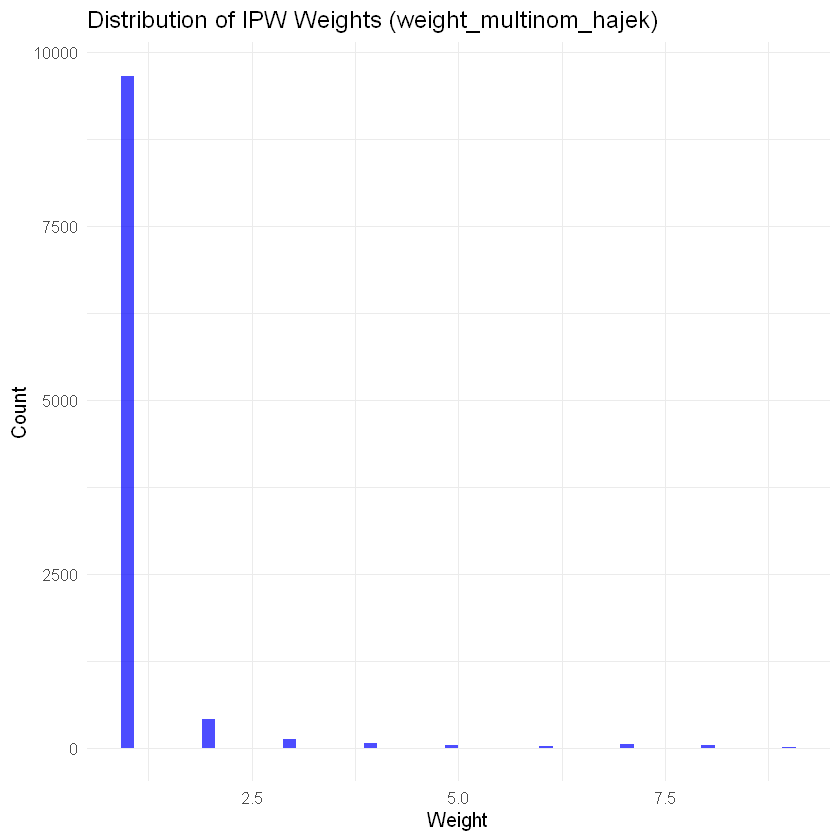

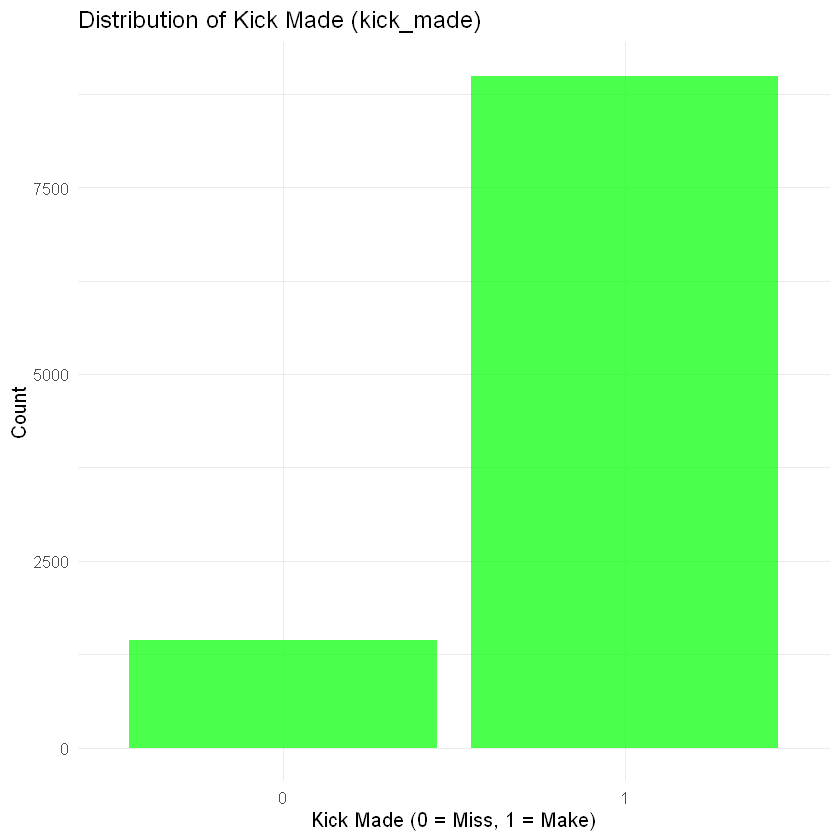

In [17]:
# Verify weights column in fg_B before CV

stopifnot("weight_multinom_hajek" %in% names(fg_B))

w <- fg_B$weight_multinom_hajek

if (any(!is.finite(w) | is.na(w) | w < 0)) {
  stop("Weights column contains NA, Inf, or negative values.")
}

if (all(w == 0)) {
  stop("All weights are zero.")
}

message("Weights column verified: all finite, non-NA, non-negative, and not all zero.")

with(fg_B, {
  print(summary(kick_made))
  cat("Distinct kickers:", dplyr::n_distinct(kicker_player_id), "\n")
  cat("NA in weights:", sum(!is.finite(weight_multinom_hajek)), "\n")
})



# Plot distribution of weights
p_weights <- ggplot2::ggplot(fg_B, ggplot2::aes(x = weight_multinom_hajek)) +
    ggplot2::geom_histogram(bins = 50, fill = "blue", alpha = 0.7) +
    ggplot2::labs(title = "Distribution of IPW Weights (weight_multinom_hajek)", x = "Weight", y = "Count") +
    ggplot2::theme_minimal(base_size = 12)

print(p_weights)

# Plot distribution of kick_made (binary outcome)
p_kick_made <- ggplot2::ggplot(fg_B, ggplot2::aes(x = factor(kick_made))) +
    ggplot2::geom_bar(fill = "green", alpha = 0.7) +
    ggplot2::labs(title = "Distribution of Kick Made (kick_made)", x = "Kick Made (0 = Miss, 1 = Make)", y = "Count") +
    ggplot2::theme_minimal(base_size = 12)

print(p_kick_made)

In [18]:
# ---- helpers (one-time) ----
build_formula <- function(base_formula, use_cf = FALSE, cf_term = "logit_pi_c") {
  f_nobars <- lme4::nobars(base_formula)
  vars <- all.vars(f_nobars)
  if (use_cf) {
    if (!(cf_term %in% vars)) base_formula <- update(base_formula, as.formula(paste0(". ~ . + ", cf_term)))
  } else {
    if (cf_term %in% vars)   base_formula <- update(base_formula, as.formula(paste0(". ~ . - ", cf_term)))
  }
  base_formula
}

assert_binary01 <- function(x, name="y") {
  xnum <- suppressWarnings(as.numeric(x))
  if (any(is.na(xnum) | !is.finite(xnum))) stop(sprintf("%s has NA/Inf", name), call.=FALSE)
  if (!all(xnum %in% c(0,1))) stop(sprintf("%s not strictly {0,1}; found: %s",
                                           name, paste(sort(unique(xnum)), collapse=", ")), call.=FALSE)
  as.integer(xnum)
}

pool_sparse_levels <- function(train_df, test_df, id_col = "kicker_player_id", min_n = 10L, repl = "REPL") {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  train_df[[id_col]] <- as.factor(train_df[[id_col]])
  test_df[[id_col]]  <- as.factor(test_df[[id_col]])
  tab <- table(train_df[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  train_df[[id_col]] <- ifelse(train_df[[id_col]] %in% keep_levels, as.character(train_df[[id_col]]), repl)
  test_df[[id_col]]  <- ifelse(test_df[[id_col]] %in% keep_levels,  as.character(test_df[[id_col]]),  repl)
  train_df[[id_col]] <- factor(train_df[[id_col]])
  test_df[[id_col]]  <- factor(test_df[[id_col]], levels = levels(train_df[[id_col]]))
  list(train = train_df, test = test_df)
}

validate_weights <- function(df, col = "weight_multinom_hajek") {
  if (!(col %in% names(df))) return(NULL)
  w <- suppressWarnings(as.numeric(df[[col]]))
  if (length(w) != nrow(df)) return(NULL)
  if (any(!is.finite(w) | is.na(w) | w < 0)) return(NULL)
  if (all(w == 0)) return(NULL)
  w
}

cap_weights <- function(w, q = 0.99) {
  w <- as.numeric(w); thr <- stats::quantile(w, q, na.rm = TRUE)
  pmin(w, thr)
}

fit_or_abort <- function(expr, tag, abort_on_error = TRUE) {
  tryCatch(expr, error = function(e) {
    msg <- sprintf("[%s] %s", tag, e$message)
    if (abort_on_error) stop(msg, call. = FALSE) else { message(msg); return(NULL) }
  })
}
predict_or_abort <- function(fit, newdata, tag, abort_on_error = TRUE) {
  if (is.null(fit)) {
    msg <- sprintf("[%s] fit is NULL", tag)
    if (abort_on_error) stop(msg, call. = FALSE) else { message(msg); return(rep(NA_real_, nrow(newdata))) }
  }
  tryCatch(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE),
           error = function(e) {
             msg <- sprintf("[%s] predict failed: %s", tag, e$message)
             if (abort_on_error) stop(msg, call. = FALSE) else { message(msg); return(rep(NA_real_, nrow(newdata))) }
           })
}

safe_auc <- function(y, p) {
  keep <- is.finite(p) & !is.na(y); yk <- y[keep]; pk <- p[keep]
  if (length(unique(yk)) < 2 || length(pk) == 0) return(NA_real_)
  suppressWarnings(suppressMessages(tryCatch(as.numeric(pROC::auc(yk, pk)), error = function(e) NA_real_)))
}
safe_brier   <- function(y, p) { k <- is.finite(p) & !is.na(y); mean((y[k]-p[k])^2) }
safe_logloss <- function(y, p) { k <- is.finite(p) & !is.na(y); pk <- pmin(pmax(p[k],1e-15),1-1e-15); yk <- y[k]; -mean(yk*log(pk)+(1-yk)*log(1-pk)) }


In [19]:
run_xfg_cv <- function(
  fg_B, base_formula,
  use_cf = FALSE,
  link   = c("cloglog","logit"),
  min_kicker_plays = 5L,
  abort_on_error = TRUE
) {
  link <- match.arg(link)
  stopifnot("fold" %in% names(fg_B))
  stopifnot(
  all(fg_B$kick_made %in% c(0L,1L)),
  "weight_multinom_hajek" %in% names(fg_B),
  is.numeric(fg_B$weight_multinom_hajek)
  )
  # clip odds of attempt if you auto-create CF term
  if (use_cf && !"logit_pi_c" %in% names(fg_B) && "p_hat_attempt_clipped" %in% names(fg_B)) {
  stopifnot(is.numeric(fg_B$p_hat_attempt_clipped))
  }

  K <- max(fg_B$fold, na.rm = TRUE)

  # strict binary globally
  fg_B$kick_made <- assert_binary01(fg_B$kick_made, "kick_made")

  # (optional) if CF requested, ensure logit_pi_c exists
  if (use_cf && !("logit_pi_c" %in% names(fg_B)) && ("p_hat_attempt_clipped" %in% names(fg_B))) {
    ph <- as.numeric(fg_B$p_hat_attempt_clipped)
    ph[!is.finite(ph) | is.na(ph)] <- 0.5  # neutral default when missing
    p <- pmin(pmax(ph, 1e-6), 1 - 1e-6)
    fg_B$logit_pi_c <- qlogis(p)
  } else if (use_cf && !("logit_pi_c" %in% names(fg_B))) {
    stop("use_cf=TRUE but logit_pi_c and p_hat_attempt_clipped are missing.", call.=FALSE)
  }

  model_formula <- build_formula(base_formula, use_cf = use_cf)
  fam <- binomial(link = link)
  ctrl <- glmmTMB::glmmTMBControl(optimizer = optim, optArgs = list(method = "BFGS"))

  oof_m1 <- vector("list", K); oof_m2 <- vector("list", K)
  fold_metrics_m1 <- vector("list", K); fold_metrics_m2 <- vector("list", K)

  for (k in seq_len(K)) {
    train_df <- fg_B[fg_B$fold != k, , drop = FALSE]
    test_df  <- fg_B[fg_B$fold == k, , drop = FALSE]

    # per-fold paranoid binary check
    train_df$kick_made <- assert_binary01(train_df$kick_made, "kick_made(train)")
    test_df$kick_made  <- assert_binary01(test_df$kick_made,  "kick_made(test)")

    # pool sparse kickers
    pooled <- pool_sparse_levels(train_df, test_df, id_col = "kicker_player_id",
                                 min_n = min_kicker_plays, repl = "REPL")
    train_df <- pooled$train; test_df <- pooled$test

    # M1: unweighted
    fit_m1_k <- fit_or_abort(
      glmmTMB::glmmTMB(model_formula, data = train_df, family = fam, control = ctrl),
      sprintf("M1 fold %d fit", k), abort_on_error
    )
    p_m1 <- predict_or_abort(fit_m1_k, test_df, sprintf("M1 fold %d", k), abort_on_error)

    # M2: IPW only if valid weights; use COLUMN weights; optional cap
    w_train <- validate_weights(train_df, "weight_multinom_hajek")
    if (is.null(w_train)) {
      stop(sprintf("[M2 fold %d] invalid/missing weight_multinom_hajek; aborting CV.", k), call. = FALSE)
    }
    train_df$w_hajek <- as.numeric(w_train)
    test_df$w_hajek  <- 1

    fit_m2_k <- fit_or_abort(
      glmmTMB::glmmTMB(model_formula, data = train_df, family = fam, weights = w_hajek, control = ctrl),
      sprintf("M2 fold %d fit", k), abort_on_error
    )
    p_m2 <- predict_or_abort(fit_m2_k, test_df, sprintf("M2 fold %d", k), abort_on_error)

    # store (guard kick_distance)
    kd <- if ("kick_distance" %in% names(test_df)) test_df$kick_distance else NA_real_
    oof_m1[[k]] <- tibble::tibble(idx = which(fg_B$fold == k), fold = k, y = test_df$kick_made,
                                  p = as.numeric(p_m1), kick_distance = kd)
    oof_m2[[k]] <- tibble::tibble(idx = which(fg_B$fold == k), fold = k, y = test_df$kick_made,
                                  p = as.numeric(p_m2), kick_distance = kd)

    fold_metrics_m1[[k]] <- tibble::tibble(fold = k, n = nrow(test_df),
                                           auc = safe_auc(test_df$kick_made, p_m1),
                                           brier = safe_brier(test_df$kick_made, p_m1),
                                           logloss = safe_logloss(test_df$kick_made, p_m1))
    fold_metrics_m2[[k]] <- tibble::tibble(fold = k, n = nrow(test_df),
                                           auc = safe_auc(test_df$kick_made, p_m2),
                                           brier = safe_brier(test_df$kick_made, p_m2),
                                           logloss = safe_logloss(test_df$kick_made, p_m2))
  }

  oof_m1_df <- dplyr::bind_rows(oof_m1); oof_m2_df <- dplyr::bind_rows(oof_m2)
  fold_metrics_m1_df <- dplyr::bind_rows(fold_metrics_m1); fold_metrics_m2_df <- dplyr::bind_rows(fold_metrics_m2)

  overall_m1 <- tibble::tibble(
    model = sprintf("M1_%s_cf_%s_minK%d", link, ifelse(use_cf,"on","off"), min_kicker_plays),
    n = sum(is.finite(oof_m1_df$p) & !is.na(oof_m1_df$y)),
    auc = safe_auc(oof_m1_df$y, oof_m1_df$p),
    brier = safe_brier(oof_m1_df$y, oof_m1_df$p),
    logloss = safe_logloss(oof_m1_df$y, oof_m1_df$p)
  )
  overall_m2 <- tibble::tibble(
    model = sprintf("M2_ipw_%s_cf_%s_minK%d",
                    link, ifelse(use_cf,"on","off"), min_kicker_plays),
    n = sum(is.finite(oof_m2_df$p) & !is.na(oof_m2_df$y)),
    auc = safe_auc(oof_m2_df$y, oof_m2_df$p),
    brier = safe_brier(oof_m2_df$y, oof_m2_df$p),
    logloss = safe_logloss(oof_m2_df$y, oof_m2_df$p)
  )

# Output dirs
reports_xfg_cv_dir <- "G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/xfg_success/cv_fg_B"
if (!dir.exists(reports_xfg_cv_dir)) dir.create(reports_xfg_cv_dir, recursive = TRUE)
reports_xfg_cv_fig_dir <- "G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/xfg_success/cv_fg_B/figs"
if (!dir.exists(reports_xfg_cv_fig_dir)) dir.create(reports_xfg_cv_fig_dir, recursive = TRUE)
  # calibration (OOF)
  calib_breaks <- c(seq(15, 70, by = 5), 70 + 1e-9)
  calib_m1 <- oof_m1_df |>
    dplyr::mutate(dist_bin = cut(kick_distance, breaks = calib_breaks, include.lowest = TRUE, right = FALSE)) |>
    dplyr::group_by(dist_bin) |>
    dplyr::summarise(n = dplyr::n(), obs = mean(y, na.rm = TRUE), est = mean(p, na.rm = TRUE), .groups = "drop")
  calib_m2 <- oof_m2_df |>
    dplyr::mutate(dist_bin = cut(kick_distance, breaks = calib_breaks, include.lowest = TRUE, right = FALSE)) |>
    dplyr::group_by(dist_bin) |>
    dplyr::summarise(n = dplyr::n(), obs = mean(y, na.rm = TRUE), est = mean(p, na.rm = TRUE), .groups = "drop")

  # Persist artifacts
  readr::write_csv(fold_metrics_m1_df, file.path(reports_xfg_cv_dir, "m1_no_cf_fg_B_cv_fold_metrics.csv"))
  readr::write_csv(overall_m1,           file.path(reports_xfg_cv_dir, "m1_no_cf_fg_B_cv_overall_metrics.csv"))
  readr::write_csv(calib_m1,             file.path(reports_xfg_cv_dir, "m1_no_cf_fg_B_cv_calibration_by_distance.csv"))
  readr::write_csv(oof_m1_df,            file.path(reports_xfg_cv_dir, "m1_no_cf_fg_B_cv_oof_predictions.csv"))

  m2_suffix <- if (use_cf) "_cf" else "_no_cf"
  readr::write_csv(fold_metrics_m2_df, file.path(reports_xfg_cv_dir, sprintf("m2%s_fg_B_cv_fold_metrics.csv", m2_suffix)))
  readr::write_csv(overall_m2,          file.path(reports_xfg_cv_dir, sprintf("m2%s_fg_B_cv_overall_metrics.csv", m2_suffix)))
  readr::write_csv(calib_m2,            file.path(reports_xfg_cv_dir, sprintf("m2%s_fg_B_cv_calibration_by_distance.csv", m2_suffix)))
  readr::write_csv(oof_m2_df,           file.path(reports_xfg_cv_dir, sprintf("m2%s_fg_B_cv_oof_predictions.csv", m2_suffix)))

  # Plots
  p_m1_cv <- plot_cal_cv(calib_m1, "xFG calibration by distance (M1 no CF, CV fg_B)")
  p_m2_cv <- plot_cal_cv(calib_m2, sprintf("xFG calibration by distance (M2%s, CV fg_B)", if (use_cf) " CF" else " no CF"))
  suppressWarnings(ggplot2::ggsave(file.path(reports_xfg_cv_fig_dir, "xfg_calibration_distance_m1_no_cf_cv_fg_B.png"), p_m1_cv, width = 11, height = 6, dpi = 300))
  suppressWarnings(ggplot2::ggsave(file.path(reports_xfg_cv_fig_dir, sprintf("xfg_calibration_distance_m2%s_cv_fg_B.png", m2_suffix)), p_m2_cv, width = 11, height = 6, dpi = 300))

  # Console summary
  cat(sprintf("CV results comparing M1_no_cf (unweighted) vs M2%s (IPW) on fg_B\n\n", if (use_cf) "_cf" else "_no_cf"))
  cat("Overall M1_no_cf:\n"); print(overall_m1)
  cat(sprintf("\nOverall M2%s (IPW):\n", if (use_cf) "_cf" else "_no_cf")); print(overall_m2)

  invisible(list(
    m1_no_cf = list( folds = fold_metrics_m1_df, overall = overall_m1, calib = calib_m1),
    m2 = list( folds = fold_metrics_m2_df, overall = overall_m2, calib = calib_m2)
  ))
}

In [20]:
set.seed(20240517)
K <- 5
dummy_gid <- as.factor(fg_B$game_id)
dummy_gid_levels <- levels(dummy_gid)
dummy_fold_map <- setNames(sample(rep(1:K, length.out = length(dummy_gid_levels))), dummy_gid_levels)
dummy_foldid <- as.integer(dummy_fold_map[as.character(dummy_gid)])

one_fold <- 1L
train <- subset(fg_B, dummy_foldid != one_fold)
test  <- subset(fg_B, dummy_foldid == one_fold)

head(train)

fit_m2_fg <- function(df, form) {
  args <- list(formula = form, data = df, family = binomial("logit"))
  if ("weight_multinom_hajek" %in% names(df)) {
    args$weights <- as.name("weight_multinom_hajek")  # <- key change
  }
  do.call(glmmTMB::glmmTMB, args)
}

fit  <- fit_m2_fg(train, m1_formula)  # your formula object
# If you have old fits that still expect .w, uncomment next line:
# test$.w <- 1

p   <- predict(fit, newdata = test, type = "response",
                allow.new.levels = TRUE, na.action = na.pass)

# sanity check
stopifnot(length(p) == nrow(test) && all(is.finite(p[is.finite(test$dist_bs_1)])))

#Show results
head(data.frame(kick_made = test$kick_made, kick_distance = test$kick_distance, p = p))

#Show metrics and calibration
metrics <- make_metrics(data.frame(kick_made = test$kick_made, kick_distance = test$kick_distance, .pred = p), model_name = "m2_fg_B_logit_one_fold")
print(metrics)



game_id,play_id,old_game_id,season,week,season_type,playoffs,qtr,game_date,home_team,⋯,dist_bs_1,dist_bs_2,dist_bs_3,dist_bs_4,dist_bs_5,dist_bs_6,dist_bs_7,fold,.pred_m0_logit,.pred_m1_logit
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<date>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
2015_01_BAL_DEN,580,2015091309,2015,1,REG,0,1,2015-09-13,DEN,⋯,0.00000,0.00000000,0.0001666667,0.25947822,0.58973528,0.15061983,0,3,0.6170289,0.7519779
2015_01_BAL_DEN,824,2015091309,2015,1,REG,0,1,2015-09-13,DEN,⋯,0.00000,0.00000000,0.0013333333,0.32014394,0.57273760,0.10578512,0,3,0.6449818,0.7480332
2015_01_BAL_DEN,1357,2015091309,2015,1,REG,0,2,2015-09-13,DEN,⋯,0.00000,0.00000000,0.0360000000,0.56434091,0.38643595,0.01322314,0,3,0.7084432,0.7065149
2015_01_BAL_DEN,1823,2015091309,2015,1,REG,0,2,2015-09-13,DEN,⋯,0.00000,0.02083333,0.4791666667,0.48046875,0.01953125,0.00000000,0,3,0.8241932,0.8599228
2015_01_BAL_DEN,2282,2015091309,2015,1,REG,0,3,2015-09-13,DEN,⋯,0.00000,0.01066667,0.4146666667,0.54091667,0.03375000,0.00000000,0,3,0.8073788,0.8528066
2015_01_BAL_DEN,3449,2015091309,2015,1,REG,0,4,2015-09-13,DEN,⋯,0.03125,0.46875000,0.4791666667,0.02083333,0.00000000,0.00000000,0,3,0.9538188,0.9609150


,kick_made,kick_distance,p
,<int>,<dbl>,<dbl>
1,1,26,0.9920685
2,1,34,0.9534238
3,1,37,0.8660930
4,1,23,0.9948830
5,1,43,0.8216008
6,1,45,0.6830273


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting direction: controls < cases



# A tibble: 1 × 8
  model       brier log_loss   auc cal_slope cal_slope_se cal_intercept cal_data
  <chr>       <dbl>    <dbl> <dbl>     <dbl>        <dbl>         <dbl> <list>  
1 m2_fg_B_lo… 0.106    0.340 0.785      6.18        0.436         -3.23 <tibble>


In [21]:
# 1) No CF, cloglog (your current setup)
#res1 <- run_xfg_cv(fg_B, base_formula = m1_formula, reports_xfg_dir, use_cf = FALSE, link = "cloglog")

# 2) No CF, logit link
#res2 <- run_xfg_cv(fg_B, base_formula = m1_formula, reports_xfg_dir, use_cf = FALSE, link = "logit")

# 3) With CF, logit link (auto-creates logit_pi_c from p_hat_attempt_clipped if missing)
res_3 <- run_xfg_cv(
  fg_B, base_formula = m1_formula,
  use_cf = TRUE,        # keep CF off
  link   = "logit",      # try logit first
  min_kicker_plays = 5, # pool sparse kickers to REPL
  abort_on_error = TRUE  # early abort on any error
)


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; . See vignette('troubleshooting'), help('diagnose')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; . See vignette('troubleshooting'), help('diagnose')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; . See vignette('troubleshooting'), help('diagnose')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; . See vignette('troubleshooting'), help('diagnose')"
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.o

CV results comparing M1_no_cf (unweighted) vs M2_cf (IPW) on fg_B

Overall M1_no_cf:
# A tibble: 1 × 5
  model                    n   auc brier logloss
  <chr>                <int> <dbl> <dbl>   <dbl>
1 M1_logit_cf_on_minK5 10432 0.779 0.105   0.340

Overall M2_cf (IPW):
# A tibble: 1 × 5
  model                        n   auc brier logloss
  <chr>                    <int> <dbl> <dbl>   <dbl>
1 M2_ipw_logit_cf_on_minK5 10432 0.767 0.108   0.349
